#**Analisis & Prediksi Penjualan Perusahaan Percetakan**

**Dataset:** Data penjualan harian perusahaan percetakan (Agustus 2022 – November 2023)

**Tujuan proyek:**
1. Membersihkan dan memvalidasi data penjualan mentah
2. Memahami pola penjualan: tren, musiman, dan produk unggulan
3. Membangun model peramalan (forecasting) pendapatan mingguan
4. Menghasilkan rekomendasi bisnis yang dapat ditindaklanjuti

## 1. Setup & Load Data

In [ ]:
# Install library tambahan yang tidak tersedia default di Colab
!pip install prophet xgboost openpyxl --quiet
print('Instalasi selesai.')

Instalasi selesai.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

def rupiah(x, pos=None):
    """Formatter sumbu grafik ke format Rupiah singkat."""
    if abs(x) >= 1e9:
        return f'{x/1e9:.1f} M'
    if abs(x) >= 1e6:
        return f'{x/1e6:.0f} Jt'
    if abs(x) >= 1e3:
        return f'{x/1e3:.0f} Rb'
    return f'{x:.0f}'

RP = mticker.FuncFormatter(rupiah)
print('Setup selesai.')

Setup selesai.


### 1.1 Upload dataset

In [ ]:
from google.colab import files
uploaded = files.upload()
NAMA_FILE = list(uploaded.keys())[0]
print(f'File terupload: {NAMA_FILE}')

Saving data_penjualan.csv to data_penjualan.csv
File terupload: data_penjualan.csv


In [ ]:
# PENTING: file ini menggunakan titik koma (;) sebagai pemisah, bukan koma.
df_raw = pd.read_csv(NAMA_FILE, sep=';')

print(f'Jumlah baris  : {df_raw.shape[0]:,}')
print(f'Jumlah kolom  : {df_raw.shape[1]}')
print()
df_raw.head(10)

Jumlah baris  : 1,076
Jumlah kolom  : 5



,Tanggal,Jenis Produk,Jumlah Order,Harga,Total
0,05/08/2022,Foodpak260,1000,1800,1800000
1,05/08/2022,FoodpakMatte245,1000,1900,1900000
2,05/08/2022,CraftLaminasi290,5000,750,3750000
3,05/08/2022,CraftLaminasi290,1000,1200,1200000
4,07/08/2022,Dupleks310,1000,1550,1550000
5,08/08/2022,Dupleks310,500,1900,950000
6,08/08/2022,Ivory270,1000,1700,1700000
7,09/08/2022,Kinstruk130,1000,1000,1000000
8,09/08/2022,HVS,1500,850,1275000
9,09/08/2022,Dupleks350,500,1800,900000


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1076 entries, 0 to 1075
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Tanggal       1076 non-null   object
 1   Jenis Produk  1076 non-null   object
 2   Jumlah Order  1076 non-null   int64 
 3   Harga         1076 non-null   int64 
 4   Total         1076 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 42.2+ KB


## 2. Audit Kualitas Data Sebelum menganalisis, kita perlu memastikan datanya layak dipercaya.

Ada empat hal yang diperiksa:
- nilai kosong,
- konsistensi aritmatika,
- duplikasi,
- dan konsistensi penamaan produk.

### 2.1 Nilai kosong (missing values)

In [ ]:
missing = pd.DataFrame({
    'Jumlah Kosong': df_raw.isna().sum(),
    'Persentase (%)': (df_raw.isna().sum() / len(df_raw) * 100).round(2)
})
missing

,Jumlah Kosong,Persentase (%)
Tanggal,0,0.00
Jenis Produk,0,0.00
Jumlah Order,0,0.00
Harga,0,0.00
Total,0,0.00


### 2.2 Konsistensi aritmatika: apakah `Total` = `Jumlah Order` × `Harga`?Ini pemeriksaan penting. Jika ada baris yang tidak konsisten, artinya ada kesalahan input dan perlu memutuskan kolom mana yang dipercaya.

In [ ]:
hitung_ulang = df_raw['Jumlah Order'] * df_raw['Harga']
tidak_cocok = df_raw[hitung_ulang != df_raw['Total']]

print(f'Baris yang TIDAK konsisten: {len(tidak_cocok)} dari {len(df_raw)}')
if len(tidak_cocok) > 0:
    display(tidak_cocok.head(10))
else:
    print('Seluruh baris konsisten. Kolom Total dapat dipercaya.')

Baris yang TIDAK konsisten: 0 dari 1076
Seluruh baris konsisten. Kolom Total dapat dipercaya.


### 2.3 Duplikasi.
Baris kembar pada data transaksi **belum tentu error** —bisa jadi memang ada dua order identik di hari yang sama (misal dua pelanggan berbeda memesan produk dan jumlah yang sama). Periksa dulu polanya sebelum memutuskan.

In [ ]:
dupes = df_raw[df_raw.duplicated(keep=False)].sort_values(['Tanggal', 'Jenis Produk'])
print(f'Jumlah baris yang punya kembaran: {len(dupes)}')
print(f'Jumlah baris duplikat persis (selain yang pertama): {df_raw.duplicated().sum()}')
print()
dupes.head(12)

Jumlah baris yang punya kembaran: 75
Jumlah baris duplikat persis (selain yang pertama): 40



,Tanggal,Jenis Produk,Jumlah Order,Harga,Total
317,01/01/2023,GreaseProof,2000,200,400000
320,01/01/2023,GreaseProof,2000,200,400000
691,03/07/2023,Dupleks310,1000,2000,2000000
696,03/07/2023,Dupleks310,1000,2000,2000000
698,03/07/2023,Dupleks310,1000,2000,2000000
1035,03/11/2023,FoodpakMatte245,1000,1600,1600000
1036,03/11/2023,FoodpakMatte245,1000,1600,1600000
507,05/04/2023,GreaseProof,1000,300,300000
508,05/04/2023,GreaseProof,1000,300,300000
346,06/01/2023,Dupleks310,1000,1800,1800000


**Keputusan:** duplikat **dipertahankan**.

Alasannya : pada data transaksi harian, order identik di tanggal yang sama adalah hal wajar untuk produk standar dengan kuantitas paket (misal 500 atau 1.000 lembar). Menghapusnya berisiko menghilangkan pendapatan yang benar-benar terjadi(*understating revenue*).

### 2.4 Konsistensi penamaan produkIni masalah terbesar di dataset ini.

In [ ]:
print(f'Jumlah nama produk unik (mentah): {df_raw["Jenis Produk"].nunique()}')
print()
print('20 nama produk terbanyak:')
print(df_raw['Jenis Produk'].value_counts().head(20))
print()
print('Contoh nama yang hanya muncul 1-2 kali (indikasi typo / varian penulisan):')
jarang = df_raw['Jenis Produk'].value_counts()
print(sorted(jarang[jarang <= 2].index.tolist())[:40])

Jumlah nama produk unik (mentah): 94

20 nama produk terbanyak:
Jenis Produk
Dupleks310          162
Ivory230            133
CraftLaminasi290    121
Dupleks350           78
GreaseProof          78
Ivory270             58
FoodpakMatte245      54
Ivory250             51
CraftFoodpak290      28
Ivory300             25
Ivory350             25
Dupleks270           24
Foodpak260Glossy     15
Foodpak260Matte      14
HVS                  14
Craft310             11
CraftLaminasi         8
Dupleks310P           8
FoodpakGlossy320      7
Dupleks400            7
Name: count, dtype: int64

Contoh nama yang hanya muncul 1-2 kali (indikasi typo / varian penulisan):
['245', '260Glossy', 'BOWL800ML', 'Bowl650mlCIS', 'Craf270', 'Craft275', 'Craft275Biasa', 'Craft290Foodpak', 'Craft290Laminasi8', 'Craft300', 'CraftFoodpak2900', 'CraftFoodpak290Laminasi', 'CraftLaminasi8', 'Cupstock', 'DUPLEKS310', 'Dupleks270Eplex', 'Dupleks310Eplex', 'Dupleks310IK', 'Dupleks350IK', 'Foodpak295Matte', 'Foodpakmatte245', 

**Temuan:** ada **94 nama produk unik**, tapi sebagian besar adalah variasi penulisan dari produk yang sama.

Contoh yang terlihat jelas:

| Penulisan berbeda | Produk sebenarnya ||---|---||

 `Dupleks310`, `Duplex310`, `dupleks310` | Dupleks 310 gsm ||

 `FoodpakMatte245`, `Foodpakmatte245` | Foodpak Matte 245 gsm ||

 `GreaseProof40`, `Greseproof40`, `Gressproff` | Greaseproof 40 gsm ||

 `CraftLaminasi290`, `Craft290Laminasi` | Craft Laminasi 290 gsm |

 Ada juga satu entri `CemerlangIndahSelaras` yang tampaknya **nama perusahaan, bukan produk** —kemungkinan salah kolom saat input. Kalau dibiarkan, analisis "produk terlaris" akan salah total karena penjualan satuproduk terpecah ke beberapa nama.

## 3. Data Cleaning & Feature Engineering

Strategi cleaning:
1. Parsing tanggal ke format datetime
2. Normalisasi nama produk (huruf besar, hapus spasi/tanda baca, perbaiki typo umum)
3. Ekstrak **kategori produk** (family) dan **gramatur** sebagai fitur terpisah4. Tambahkan fitur waktu (bulan, hari, minggu)

In [ ]:
df = df_raw.copy()

# --- 3.1 Parsing tanggal ---
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%d/%m/%Y', errors='coerce')
print(f'Tanggal gagal di-parsing: {df["Tanggal"].isna().sum()}')
print(f'Rentang data: {df["Tanggal"].min():%d %b %Y}  s/d  {df["Tanggal"].max():%d %b %Y}')
print(f'Jumlah hari transaksi unik: {df["Tanggal"].nunique()}')

Tanggal gagal di-parsing: 0
Rentang data: 05 Aug 2022  s/d  15 Nov 2023
Jumlah hari transaksi unik: 284


In [ ]:
# --- 3.2 Normalisasi nama produk ---

def normalisasi_nama(nama):
    """Ubah ke huruf besar, hapus karakter non-alfanumerik, perbaiki typo umum."""
    s = str(nama).upper()
    s = re.sub(r'[^A-Z0-9]', '', s)          # hapus spasi, titik, strip, dll

    # perbaikan typo yang teridentifikasi saat audit
    koreksi = {
        'DUPLEX': 'DUPLEKS',
        'GRESEPROOF': 'GREASEPROOF',
        'GRESSPROFF': 'GREASEPROOF',
        'GRESPROOF': 'GREASEPROOF',
        'CRAF270': 'CRAFT270',
    }
    for salah, benar in koreksi.items():
        s = s.replace(salah, benar)
    return s

df['produk_bersih'] = df['Jenis Produk'].apply(normalisasi_nama)

print(f'Nama unik sebelum : {df["Jenis Produk"].nunique()}')
print(f'Nama unik sesudah : {df["produk_bersih"].nunique()}')

Nama unik sebelum : 94
Nama unik sesudah : 87


In [ ]:
# --- 3.3 Ekstraksi kategori produk (family) ---

FAMILY = ['DUPLEKS', 'IVORY', 'CRAFT', 'FOODPAK', 'GREASEPROOF',
          'HVS', 'KINSTRUK', 'BOWL', 'CUPSTOCK']

def ambil_family(nama):
    for f in FAMILY:
        if nama.startswith(f):
            return f.title()
    return 'Lainnya'

def ambil_gramatur(nama):
    """Ambil angka 3 digit pertama sebagai gramatur (gsm). 130-800 dianggap valid."""
    m = re.search(r'(\d{3})', nama)
    if m:
        g = int(m.group(1))
        return g if 100 <= g <= 900 else np.nan
    return np.nan

df['Kategori'] = df['produk_bersih'].apply(ambil_family)
df['Gramatur'] = df['produk_bersih'].apply(ambil_gramatur)

ringkas = df.groupby('Kategori').agg(
    Transaksi=('Total', 'size'),
    Total_Pendapatan=('Total', 'sum')
).sort_values('Total_Pendapatan', ascending=False)
ringkas['Share_Pendapatan_%'] = (ringkas['Total_Pendapatan'] / ringkas['Total_Pendapatan'].sum() * 100).round(1)
ringkas

,Transaksi,Total_Pendapatan,Share_Pendapatan_%
Kategori,,,
Dupleks,299,803015000,31.80
Ivory,308,677101000,26.80
Craft,199,472525000,18.70
Foodpak,126,383200000,15.20
Hvs,15,66025000,2.60
Greaseproof,85,43900000,1.70
Kinstruk,13,38468550,1.50
Lainnya,28,25775376,1.00
Bowl,2,11300000,0.40


Dari 94 nama yang berantakan, kita dapat **9 kategori produk yang bermakna**. Lima kategori teratas mencakup lebih dari 95% transaksi — jauh lebih mudah dianalisis.

In [ ]:
# --- 3.4 Fitur waktu ---
df['Tahun']       = df['Tanggal'].dt.year
df['Bulan']       = df['Tanggal'].dt.month
df['Nama_Bulan']  = df['Tanggal'].dt.strftime('%b %Y')
df['Hari']        = df['Tanggal'].dt.day_name()
df['Minggu_ke']   = df['Tanggal'].dt.isocalendar().week.astype(int)
df['Periode']     = df['Tanggal'].dt.to_period('M')

# --- 3.5 Deteksi outlier dengan metode IQR (untuk ditandai, bukan dihapus) ---
Q1, Q3 = df['Total'].quantile([0.25, 0.75])
IQR = Q3 - Q1
batas_atas = Q3 + 1.5 * IQR
df['is_outlier'] = df['Total'] > batas_atas

print(f'Batas atas outlier: Rp {batas_atas:,.0f}')
print(f'Jumlah transaksi outlier: {df["is_outlier"].sum()} ({df["is_outlier"].mean()*100:.1f}%)')
print()
print('10 transaksi terbesar:')
df.nlargest(10, 'Total')[['Tanggal', 'Jenis Produk', 'Kategori', 'Jumlah Order', 'Harga', 'Total']]

Batas atas outlier: Rp 5,531,250
Jumlah transaksi outlier: 69 (6.4%)

10 transaksi terbesar:


,Tanggal,Jenis Produk,Kategori,Jumlah Order,Harga,Total
521,2023-04-14,Kinstruk150gsm,Kinstruk,215,99970,21493550
561,2023-05-03,Duplex310,Dupleks,10000,1100,11000000
431,2023-02-21,HVS,Hvs,40000,250,10000000
582,2023-05-10,Ivory350,Ivory,10000,950,9500000
609,2023-05-25,Ivory350,Ivory,10000,900,9000000
873,2023-08-31,Ivory350,Ivory,10000,900,9000000
883,2023-09-03,Ivory350,Ivory,10000,900,9000000
957,2023-10-05,Ivory350,Ivory,10000,900,9000000
1015,2023-10-25,Ivory350,Ivory,10000,900,9000000
686,2023-07-01,FoodpakGlossy320,Foodpak,2000,4300,8600000


**Catatan tentang outlier:** transaksi bernilai besar **tidak dihapus**. Dalam konteks B2B percetakan, order besar adalah bagian nyata dari bisnis — menghapusnya akan membuat model meremehkan (*underestimate*) potensi pendapatan. Outlier hanya ditandai agar bisa dianalisis pengaruhnya.

## 4. Exploratory Data Analysis

### 4.1 Ringkasan umum

In [ ]:
total_pendapatan = df['Total'].sum()
total_order      = df['Jumlah Order'].sum()
n_hari           = (df['Tanggal'].max() - df['Tanggal'].min()).days + 1

print('=' * 55)
print('RINGKASAN PENJUALAN')
print('=' * 55)
print(f'Periode                  : {df["Tanggal"].min():%d %b %Y} - {df["Tanggal"].max():%d %b %Y}')
print(f'Rentang kalender         : {n_hari} hari')
print(f'Hari dengan transaksi    : {df["Tanggal"].nunique()} hari ({df["Tanggal"].nunique()/n_hari*100:.1f}%)')
print(f'Jumlah transaksi         : {len(df):,}')
print(f'Total pendapatan         : Rp {total_pendapatan:,.0f}')
print(f'Total unit terjual       : {total_order:,} unit')
print(f'Rata-rata per transaksi  : Rp {df["Total"].mean():,.0f}')
print(f'Median per transaksi     : Rp {df["Total"].median():,.0f}')
print(f'Transaksi terbesar       : Rp {df["Total"].max():,.0f}')
print(f'Transaksi terkecil       : Rp {df["Total"].min():,.0f}')
print('=' * 55)

RINGKASAN PENJUALAN
Periode                  : 05 Aug 2022 - 15 Nov 2023
Rentang kalender         : 468 hari
Hari dengan transaksi    : 284 hari (60.7%)
Jumlah transaksi         : 1,076
Total pendapatan         : Rp 2,524,109,926
Total unit terjual       : 2,049,708 unit
Rata-rata per transaksi  : Rp 2,345,827
Median per transaksi     : Rp 1,800,000
Transaksi terbesar       : Rp 21,493,550
Transaksi terkecil       : Rp 15,376


### 4.2 Distribusi nilai transaksi

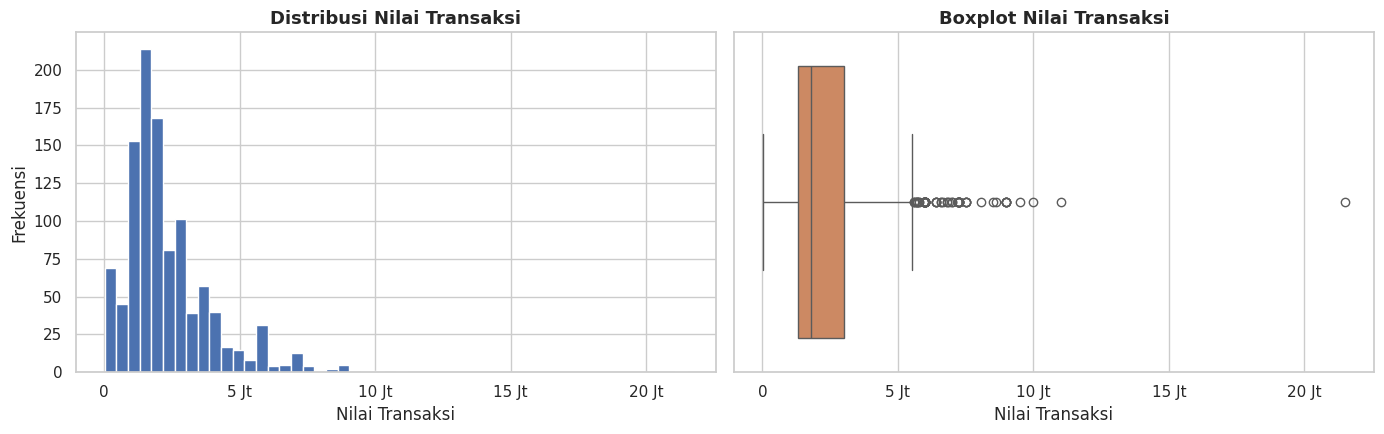

Skewness: 2.61  (>0 berarti condong ke kanan / right-skewed)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(df['Total'], bins=50, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribusi Nilai Transaksi')
axes[0].set_xlabel('Nilai Transaksi')
axes[0].set_ylabel('Frekuensi')
axes[0].xaxis.set_major_formatter(RP)

sns.boxplot(x=df['Total'], ax=axes[1], color='#DD8452')
axes[1].set_title('Boxplot Nilai Transaksi')
axes[1].set_xlabel('Nilai Transaksi')
axes[1].xaxis.set_major_formatter(RP)

plt.tight_layout()
plt.show()

print(f'Skewness: {df["Total"].skew():.2f}  (>0 berarti condong ke kanan / right-skewed)')

Distribusinya **right-skewed**: mayoritas transaksi bernilai kecil–menengah, dengan sedikit order besar yang menarik ekor distribusi ke kanan. Ini pola khas bisnis B2B —banyak order rutin, sesekali order jumbo.

### 4.3 Tren pendapatan bulanan

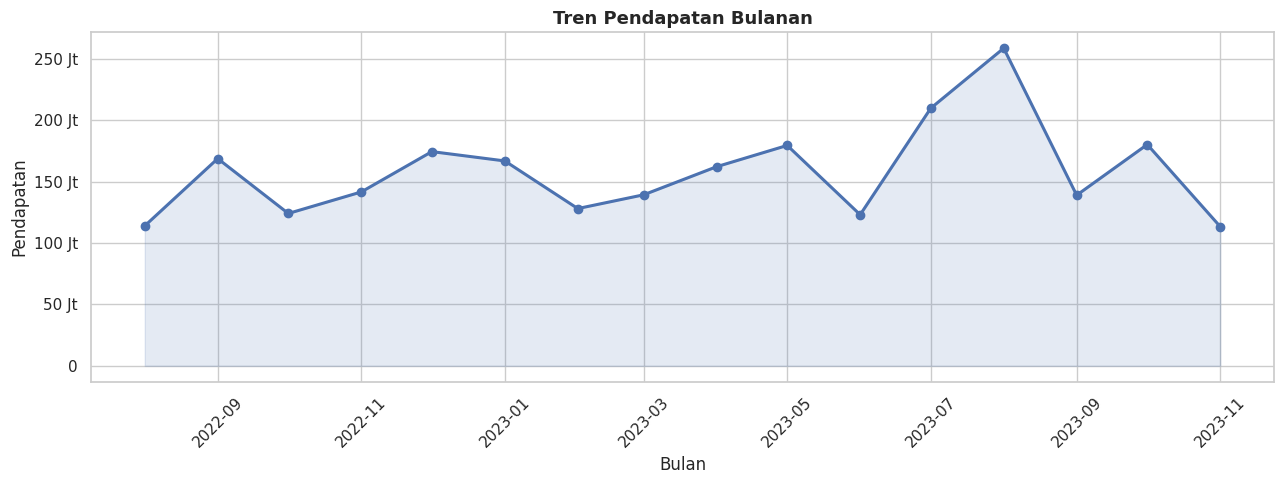

,Pendapatan,Transaksi,Unit
Periode,,,
2022-08-01 00:00:00,"Rp 114,070,000",55,"80,500"
2022-09-01 00:00:00,"Rp 168,840,000",68,"135,000"
2022-10-01 00:00:00,"Rp 124,147,500",49,"102,700"
2022-11-01 00:00:00,"Rp 141,677,500",63,"118,250"
2022-12-01 00:00:00,"Rp 174,540,000",75,"131,700"
2023-01-01 00:00:00,"Rp 166,937,500",73,"135,000"
2023-02-01 00:00:00,"Rp 128,140,376",55,"132,874"
2023-03-01 00:00:00,"Rp 139,353,500",60,"102,620"
2023-04-01 00:00:00,"Rp 162,246,050",62,"131,715"


In [ ]:
bulanan = df.groupby('Periode').agg(
    Pendapatan=('Total', 'sum'),
    Transaksi=('Total', 'size'),
    Unit=('Jumlah Order', 'sum')
)
bulanan.index = bulanan.index.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(bulanan.index, bulanan['Pendapatan'], marker='o', lw=2.2, color='#4C72B0')
ax.fill_between(bulanan.index, bulanan['Pendapatan'], alpha=0.15, color='#4C72B0')
ax.set_title('Tren Pendapatan Bulanan')
ax.set_xlabel('Bulan')
ax.set_ylabel('Pendapatan')
ax.yaxis.set_major_formatter(RP)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

bulanan.style.format({'Pendapatan': 'Rp {:,.0f}', 'Unit': '{:,.0f}'})

### 4.4 Produk terlaris & analisis Pareto (80/20)

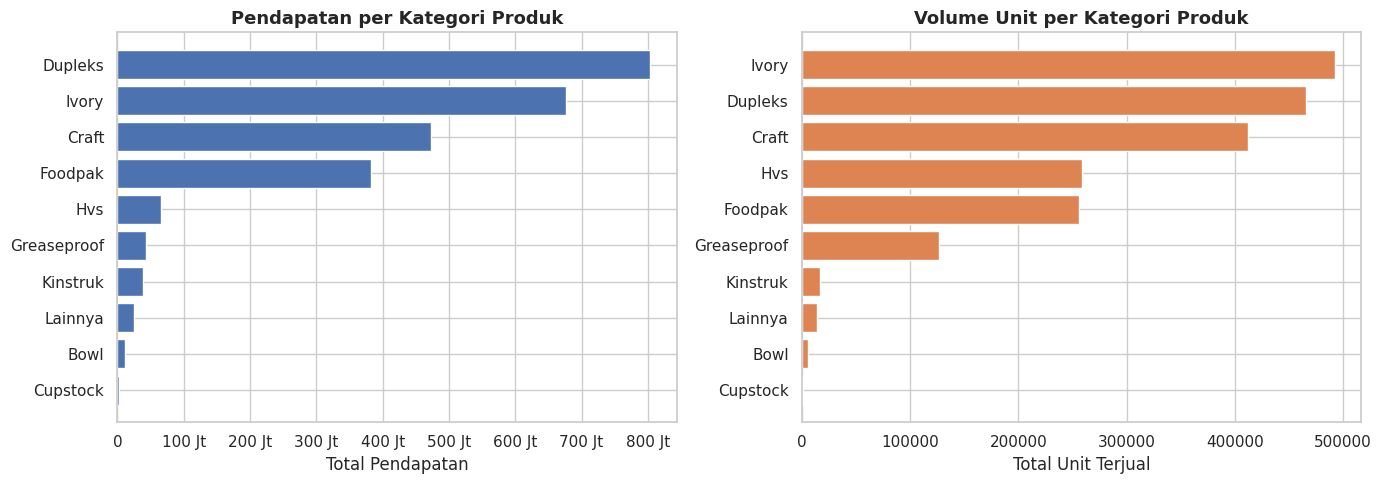

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Berdasarkan pendapatan
top_pendapatan = df.groupby('Kategori')['Total'].sum().sort_values(ascending=True)
axes[0].barh(top_pendapatan.index, top_pendapatan.values, color='#4C72B0')
axes[0].set_title('Pendapatan per Kategori Produk')
axes[0].set_xlabel('Total Pendapatan')
axes[0].xaxis.set_major_formatter(RP)

# Berdasarkan volume unit
top_unit = df.groupby('Kategori')['Jumlah Order'].sum().sort_values(ascending=True)
axes[1].barh(top_unit.index, top_unit.values, color='#DD8452')
axes[1].set_title('Volume Unit per Kategori Produk')
axes[1].set_xlabel('Total Unit Terjual')

plt.tight_layout()
plt.show()

13 dari 87 produk (15%) menyumbang 80% total pendapatan.



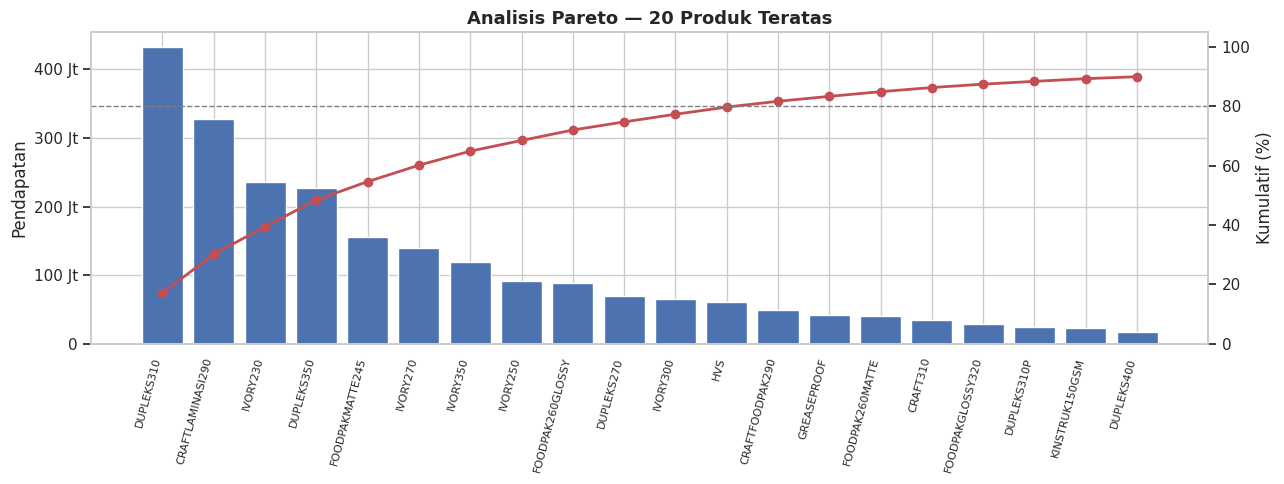

,Pendapatan,Kumulatif_%
produk_bersih,,
DUPLEKS310,"Rp 432,590,000",17.1%
CRAFTLAMINASI290,"Rp 327,937,500",30.1%
IVORY230,"Rp 235,306,000",39.5%
DUPLEKS350,"Rp 227,375,000",48.5%
FOODPAKMATTE245,"Rp 156,100,000",54.6%
IVORY270,"Rp 139,630,000",60.2%
IVORY350,"Rp 119,700,000",64.9%
IVORY250,"Rp 91,100,000",68.5%
FOODPAK260GLOSSY,"Rp 88,900,000",72.1%


In [ ]:
# Analisis Pareto pada level produk spesifik
pareto = df.groupby('produk_bersih')['Total'].sum().sort_values(ascending=False)
pareto_df = pd.DataFrame({'Pendapatan': pareto})
pareto_df['Kumulatif_%'] = pareto_df['Pendapatan'].cumsum() / pareto_df['Pendapatan'].sum() * 100

n_80 = (pareto_df['Kumulatif_%'] <= 80).sum() + 1
print(f'{n_80} dari {len(pareto_df)} produk ({n_80/len(pareto_df)*100:.0f}%) '
      f'menyumbang 80% total pendapatan.')
print()

fig, ax1 = plt.subplots(figsize=(13, 5))
top20 = pareto_df.head(20)
ax1.bar(range(len(top20)), top20['Pendapatan'], color='#4C72B0')
ax1.set_xticks(range(len(top20)))
ax1.set_xticklabels(top20.index, rotation=75, ha='right', fontsize=8)
ax1.set_ylabel('Pendapatan')
ax1.yaxis.set_major_formatter(RP)

ax2 = ax1.twinx()
ax2.plot(range(len(top20)), top20['Kumulatif_%'], color='#C44E52', marker='o', lw=2)
ax2.axhline(80, ls='--', color='gray', lw=1)
ax2.set_ylabel('Kumulatif (%)')
ax2.set_ylim(0, 105)
ax2.grid(False)

plt.title('Analisis Pareto — 20 Produk Teratas')
plt.tight_layout()
plt.show()

pareto_df.head(15).style.format({'Pendapatan': 'Rp {:,.0f}', 'Kumulatif_%': '{:.1f}%'})

### 4.5 Pola hari dalam seminggu

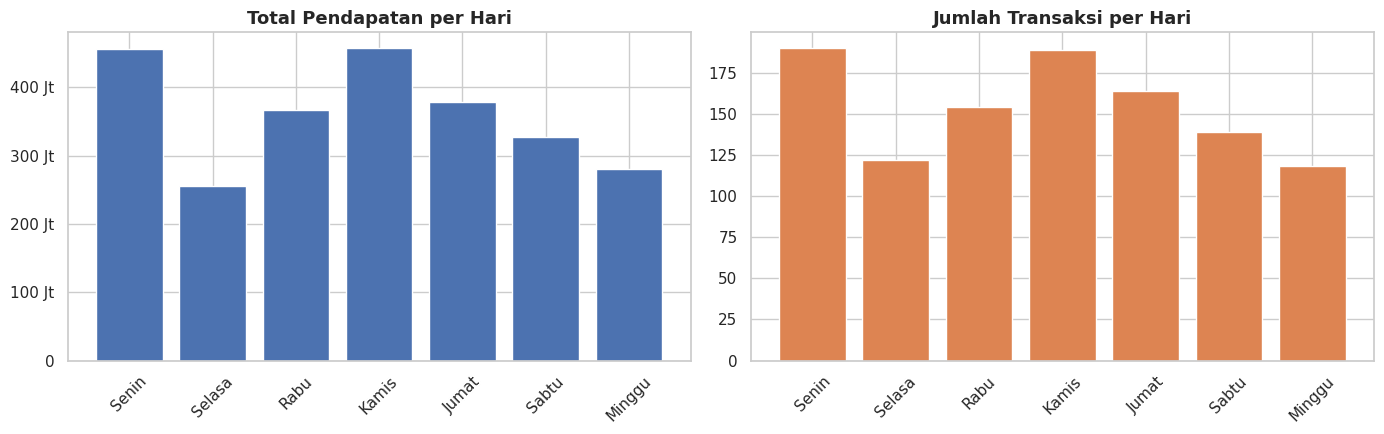

,Pendapatan,Transaksi
Senin,456237500,190
Selasa,256216000,122
Rabu,366292500,154
Kamis,457597500,189
Jumat,379026050,164
Sabtu,327970000,139
Minggu,280770376,118


In [ ]:
urutan_hari = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
label_hari  = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']

per_hari = df.groupby('Hari').agg(
    Pendapatan=('Total', 'sum'),
    Transaksi=('Total', 'size')
).reindex(urutan_hari).fillna(0)
per_hari.index = label_hari

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(per_hari.index, per_hari['Pendapatan'], color='#4C72B0')
axes[0].set_title('Total Pendapatan per Hari')
axes[0].yaxis.set_major_formatter(RP)
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(per_hari.index, per_hari['Transaksi'], color='#DD8452')
axes[1].set_title('Jumlah Transaksi per Hari')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
per_hari

### 4.6 Analisis harga

Menarik untuk dicek: apakah order dalam jumlah besar mendapat harga satuan lebih murah(indikasi adanya diskon volume)?

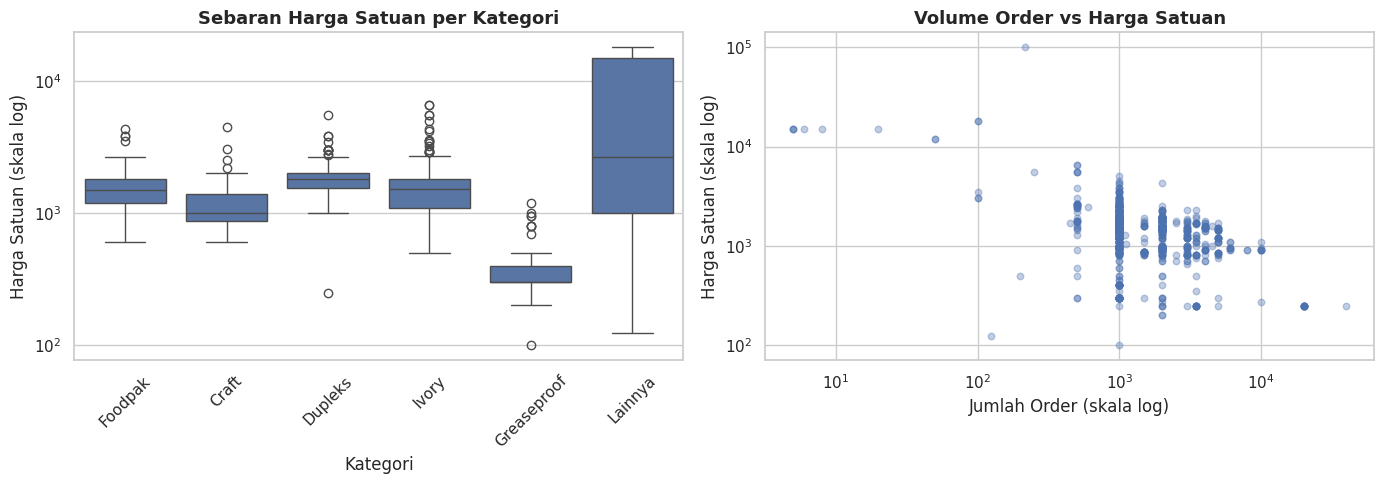

Korelasi log(Jumlah Order) vs log(Harga): -0.446
Nilai negatif mengindikasikan adanya diskon volume (makin banyak order, makin murah harga satuannya).


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Harga per kategori
kategori_utama = df['Kategori'].value_counts().head(6).index
subset = df[df['Kategori'].isin(kategori_utama)]
sns.boxplot(data=subset, x='Kategori', y='Harga', ax=axes[0])
axes[0].set_title('Sebaran Harga Satuan per Kategori')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_yscale('log')
axes[0].set_ylabel('Harga Satuan (skala log)')

# Hubungan volume vs harga satuan
axes[1].scatter(df['Jumlah Order'], df['Harga'], alpha=0.35, s=22, color='#4C72B0')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Jumlah Order (skala log)')
axes[1].set_ylabel('Harga Satuan (skala log)')
axes[1].set_title('Volume Order vs Harga Satuan')

plt.tight_layout()
plt.show()

korelasi = np.corrcoef(np.log1p(df['Jumlah Order']), np.log1p(df['Harga']))[0, 1]
print(f'Korelasi log(Jumlah Order) vs log(Harga): {korelasi:.3f}')
print('Nilai negatif mengindikasikan adanya diskon volume '
      '(makin banyak order, makin murah harga satuannya).')

## 5. Persiapan Time Series
Kenapa mingguan, bukan harian? Ini keputusan metodologis yang penting, lihat data.

In [ ]:
# Agregasi harian, lalu isi hari tanpa transaksi dengan 0
harian = df.groupby('Tanggal')['Total'].sum()
rentang_penuh = pd.date_range(harian.index.min(), harian.index.max(), freq='D')
ts_harian = harian.reindex(rentang_penuh, fill_value=0)

n_kosong = (ts_harian == 0).sum()
print(f'Total hari dalam kalender      : {len(ts_harian)}')
print(f'Hari TANPA transaksi           : {n_kosong} ({n_kosong/len(ts_harian)*100:.1f}%)')
print(f'Rata-rata pendapatan harian    : Rp {ts_harian.mean():,.0f}')
print(f'Standar deviasi harian         : Rp {ts_harian.std():,.0f}')
print(f'Koefisien variasi (CV) harian  : {ts_harian.std()/ts_harian.mean():.2f}')

Total hari dalam kalender      : 468
Hari TANPA transaksi           : 184 (39.3%)
Rata-rata pendapatan harian    : Rp 5,393,397
Standar deviasi harian         : Rp 9,984,605
Koefisien variasi (CV) harian  : 1.85


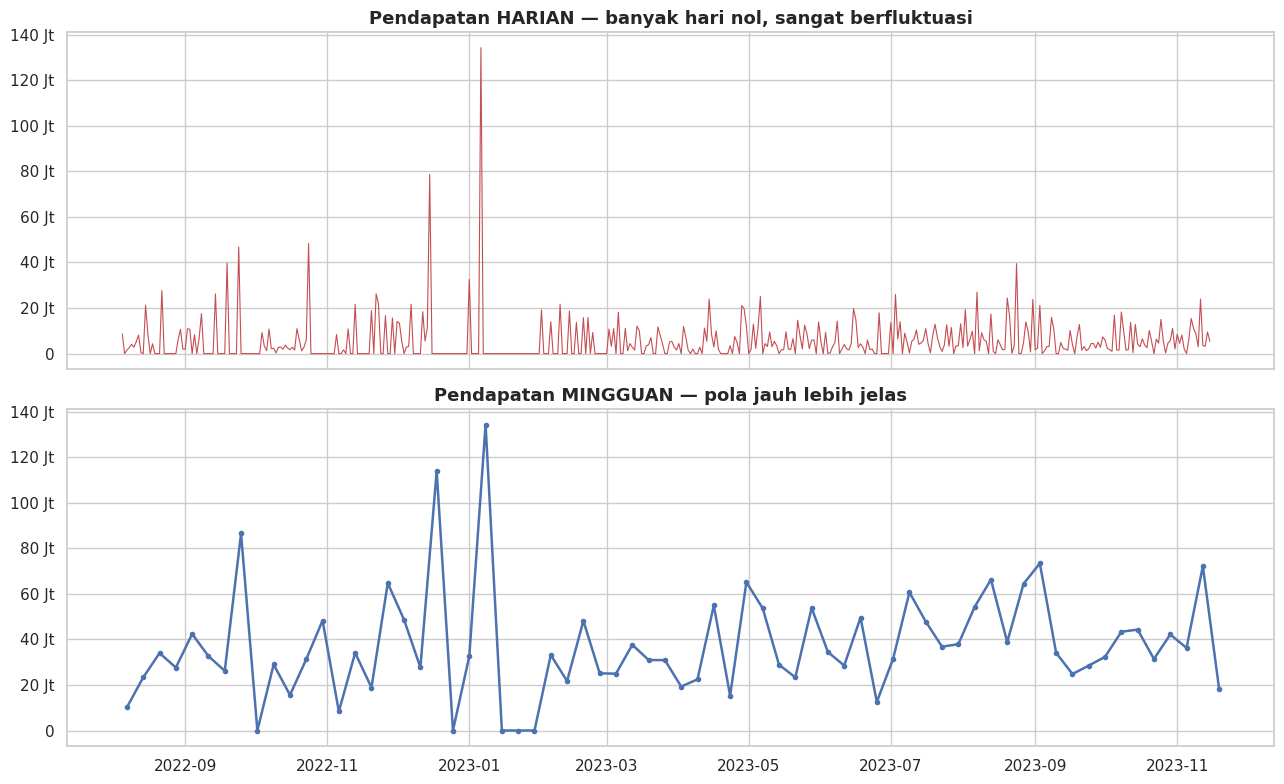

CV harian   : 1.85
CV mingguan : 0.65  <- jauh lebih stabil


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(ts_harian.index, ts_harian.values, lw=0.8, color='#C44E52')
axes[0].set_title('Pendapatan HARIAN — banyak hari nol, sangat berfluktuasi')
axes[0].yaxis.set_major_formatter(RP)

ts_mingguan = ts_harian.resample('W').sum()
axes[1].plot(ts_mingguan.index, ts_mingguan.values, lw=1.8, color='#4C72B0', marker='o', ms=3)
axes[1].set_title('Pendapatan MINGGUAN — pola jauh lebih jelas')
axes[1].yaxis.set_major_formatter(RP)

plt.tight_layout()
plt.show()

print(f'CV harian   : {ts_harian.std()/ts_harian.mean():.2f}')
print(f'CV mingguan : {ts_mingguan.std()/ts_mingguan.mean():.2f}  <- jauh lebih stabil')

**Kesimpulan:** sekitar **39% hari kalender tidak punya transaksi sama sekali** (hari libur, akhir pekan, atau memang tidak ada order).

Meramalkan data harian dengan proporsi nol sebesar ini akan menghasilkan model yang tidak dapat diandalkan.

Agregasi ke level **mingguan** mengurangi noise secara signifikan (lihat penurunankoefisien variasi) sambil tetap mempertahankan informasi tren dan musiman.

Ini granularitas yang juga lebih relevan untuk keputusan bisnis seperti perencanaa nstok bahan baku.

In [ ]:
# Data time series final untuk modeling
ts = ts_harian.resample('W').sum()
ts.name = 'Pendapatan'

# Buang minggu pertama & terakhir jika tidak lengkap (menghindari bias periode parsial)
ts = ts.iloc[1:-1]

print(f'Jumlah observasi mingguan : {len(ts)}')
print(f'Periode                   : {ts.index.min():%d %b %Y} s/d {ts.index.max():%d %b %Y}')
print(f'Rata-rata per minggu      : Rp {ts.mean():,.0f}')
ts.head()

Jumlah observasi mingguan : 66
Periode                   : 14 Aug 2022 s/d 12 Nov 2023
Rata-rata per minggu      : Rp 37,815,113


,Pendapatan
2022-08-14,23325000
2022-08-21,34000000
2022-08-28,27645000
2022-09-04,42390000
2022-09-11,32650000


## 6. Dekomposisi & Uji Stasioneritas

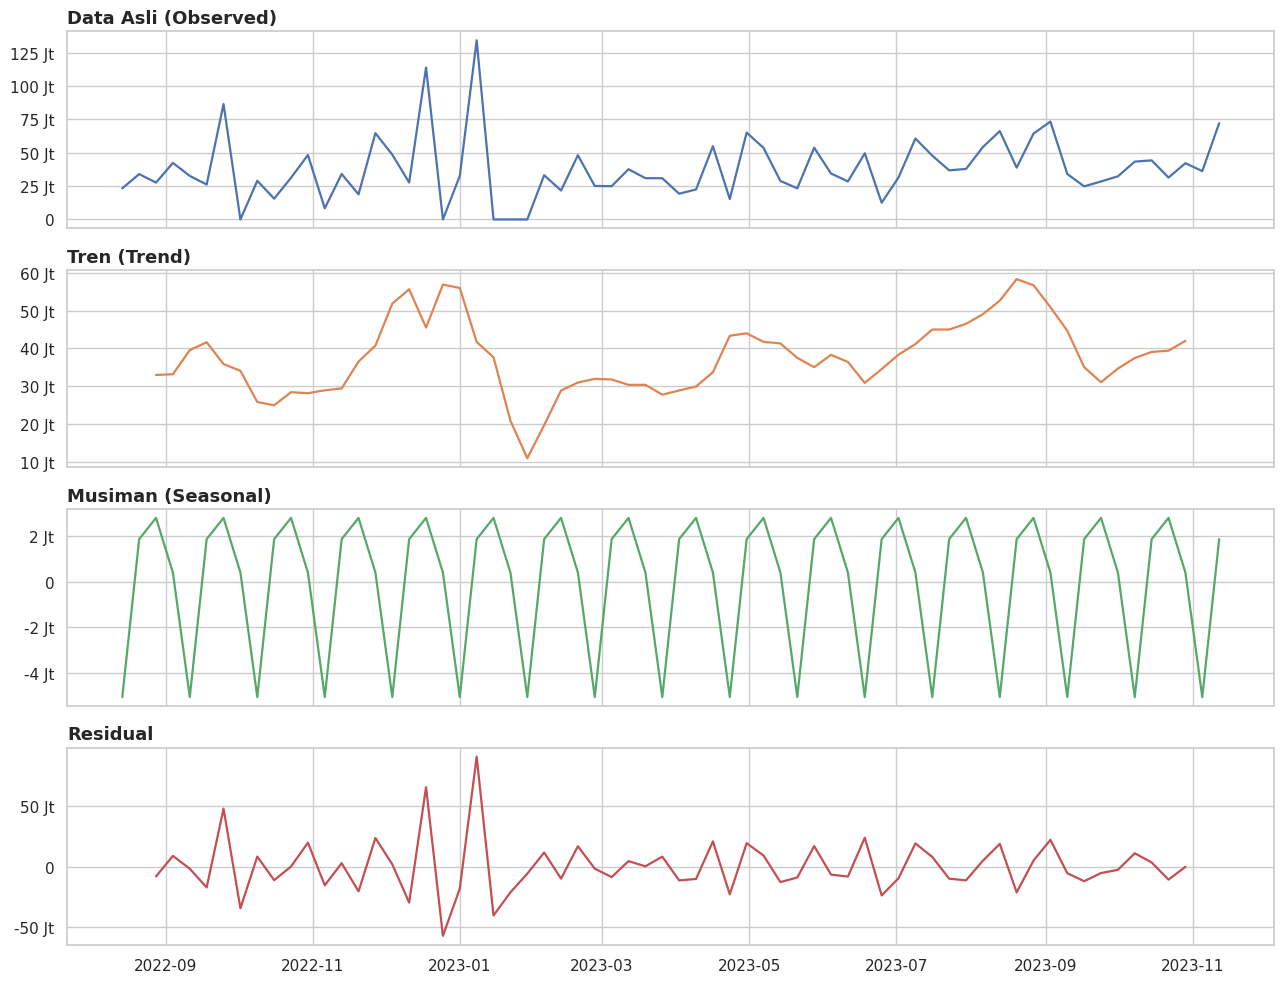

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

dekomposisi = seasonal_decompose(ts, model='additive', period=4)  # period=4 -> siklus bulanan

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
komponen = [
    (dekomposisi.observed, 'Data Asli (Observed)', '#4C72B0'),
    (dekomposisi.trend,    'Tren (Trend)',          '#DD8452'),
    (dekomposisi.seasonal, 'Musiman (Seasonal)',    '#55A868'),
    (dekomposisi.resid,    'Residual',              '#C44E52'),
]
for ax, (data, judul, warna) in zip(axes, komponen):
    ax.plot(data.index, data.values, color=warna, lw=1.6)
    ax.set_title(judul, loc='left')
    ax.yaxis.set_major_formatter(RP)

plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

def uji_adf(series, nama='Series'):
    hasil = adfuller(series.dropna())
    print(f'--- Uji Augmented Dickey-Fuller: {nama} ---')
    print(f'Statistik ADF : {hasil[0]:.4f}')
    print(f'p-value       : {hasil[1]:.4f}')
    for kunci, nilai in hasil[4].items():
        print(f'  Nilai kritis {kunci}: {nilai:.4f}')
    if hasil[1] < 0.05:
        print('Kesimpulan    : STASIONER (tolak H0)')
    else:
        print('Kesimpulan    : TIDAK stasioner (gagal tolak H0) -> perlu differencing')
    print()

uji_adf(ts, 'Pendapatan Mingguan')

--- Uji Augmented Dickey-Fuller: Pendapatan Mingguan ---
Statistik ADF : -4.0730
p-value       : 0.0011
  Nilai kritis 1%: -3.5387
  Nilai kritis 5%: -2.9086
  Nilai kritis 10%: -2.5919
Kesimpulan    : STASIONER (tolak H0)



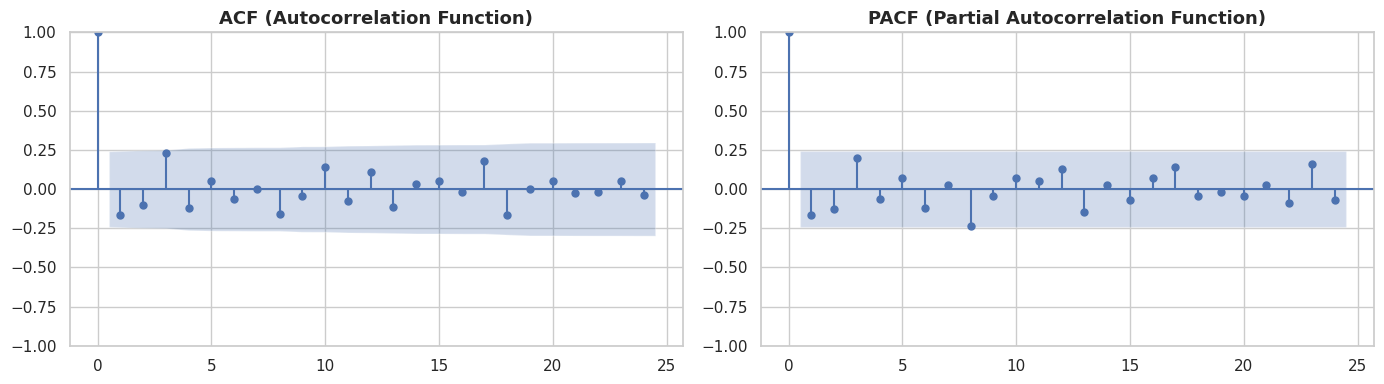

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts, lags=24, ax=axes[0])
axes[0].set_title('ACF (Autocorrelation Function)')
plot_pacf(ts, lags=24, ax=axes[1], method='ywm')
axes[1].set_title('PACF (Partial Autocorrelation Function)')
plt.tight_layout()
plt.show()

ACF dan PACF membantu menentukan orde model ARIMA. Lag yang melewati area biru menunjukkan autokorelasi yang signifikan secara statistik.

## 7. Modeling: Forecasting
Setup evaluasiKita bagi data secara **kronologis** (bukan acak — ini wajib untuk time series):data terakhir dijadikan test set untuk menguji kemampuan model meramal ke depan.

Model yang dibandingkan:
1. **Naive** — prediksi = nilai minggu terakhir (baseline)
2. **Seasonal Naive** — prediksi = nilai 4 minggu lalu
3. **Moving Average** — rata-rata 4 minggu terakhir
4. **SARIMA** — model statistik time series klasik
5. **Prophet** — model dari Meta, tangguh terhadap data tidak rapi
6. **Random Forest** — machine learning dengan fitur lag
7. **Holt-Winters** — exponential smoothing
8. **XGBoost** — gradient boosting dengan fitur lag
9. **Ensemble** — rata-rata beberapa model Baseline sederhana **wajib** ada. Model canggih yang kalah dari Naive artinya tidak memberi nilai tambah apa pun.

Data latih (train) : 58 minggu  (14 Aug 2022 - 17 Sep 2023)
Data uji (test)    : 8 minggu  (24 Sep 2023 - 12 Nov 2023)


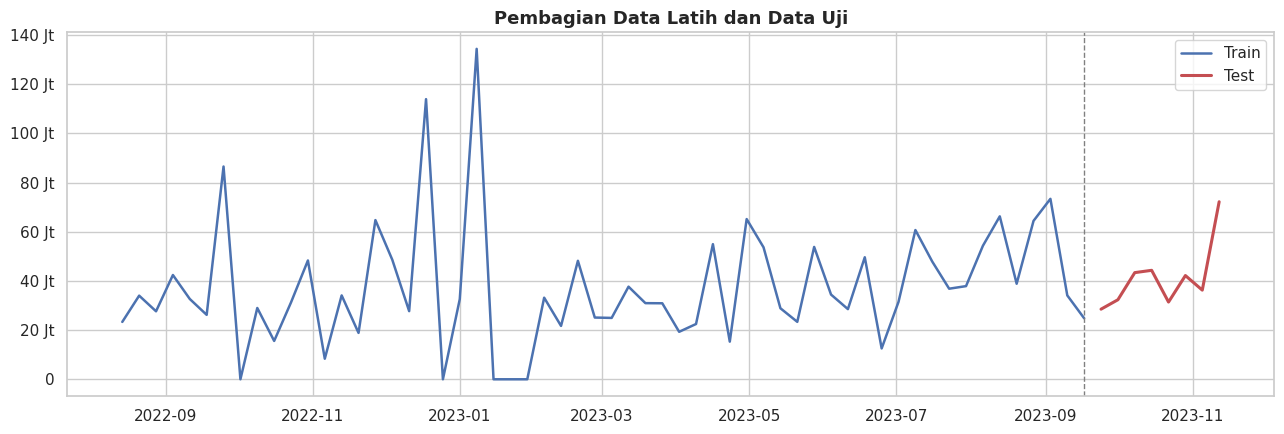

In [ ]:
HORIZON = 8   # meramal 8 minggu ke depan

train = ts.iloc[:-HORIZON]
test  = ts.iloc[-HORIZON:]

print(f'Data latih (train) : {len(train)} minggu  ({train.index.min():%d %b %Y} - {train.index.max():%d %b %Y})')
print(f'Data uji (test)    : {len(test)} minggu  ({test.index.min():%d %b %Y} - {test.index.max():%d %b %Y})')

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(train.index, train.values, label='Train', color='#4C72B0', lw=1.8)
ax.plot(test.index, test.values, label='Test', color='#C44E52', lw=2.2)
ax.axvline(train.index[-1], ls='--', color='gray', lw=1)
ax.set_title('Pembagian Data Latih dan Data Uji')
ax.yaxis.set_major_formatter(RP)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
def evaluasi(y_true, y_pred, nama_model):
    """Hitung metrik evaluasi forecasting."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    # MAPE hanya dihitung pada nilai aktual bukan nol
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {'Model': nama_model, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}

hasil = []       # menampung metrik tiap model
prediksi = {}    # menampung hasil prediksi tiap model

### 7.1 Model Baseline

In [ ]:
# --- Naive: nilai terakhir diulang ---
pred_naive = np.repeat(train.iloc[-1], HORIZON)
prediksi['Naive'] = pred_naive
hasil.append(evaluasi(test, pred_naive, 'Naive'))

# --- Seasonal Naive: ambil nilai 4 minggu sebelumnya ---
pred_snaive = np.array([train.iloc[-4 + (i % 4)] for i in range(HORIZON)])
prediksi['Seasonal Naive'] = pred_snaive
hasil.append(evaluasi(test, pred_snaive, 'Seasonal Naive'))

# --- Moving Average 4 minggu ---
pred_ma = np.repeat(train.iloc[-4:].mean(), HORIZON)
prediksi['Moving Average'] = pred_ma
hasil.append(evaluasi(test, pred_ma, 'Moving Average (4)'))

pd.DataFrame(hasil).style.format({'MAE': 'Rp {:,.0f}', 'RMSE': 'Rp {:,.0f}', 'MAPE (%)': '{:.2f}'})

,Model,MAE,RMSE,MAPE (%)
0,Naive,"Rp 16,513,125","Rp 20,965,210",35.32
1,Seasonal Naive,"Rp 27,424,375","Rp 31,121,121",71.10
2,Moving Average (4),"Rp 13,604,844","Rp 15,116,828",36.19


### 7.2 SARIMA
Cari kombinasi parameter terbaik dengan *grid search* berdasarkan nilai AIC. **Namun ada batasan penting yang perlu diterapkan pada ruang pencarian.** Uji ADF di bagian 6 menunjukkan data kita sudah **stasioner**. Artinya kebutuhan *differencing* rendah. Kalau grid search dibiarkan mencoba `d=2` atau `D=1` secara bebas, AIC cenderung memilihnya karena model yang lebih kompleks selalu terlihat "lebih pas"pada data latih — padahal pada deret pendek (hanya 58 minggu), *over-differencing* menghasilkan ekstrapolasi tren yang meledak dan prediksi yang tidak masuk akal.>

**Ini bukan teori.** Saat menjalankan grid search tanpa batasan, AIC memilih> `SARIMA(2,2,2)x(0,1,1,4)` yang menghasilkan MAPE 39,8% — **lebih buruk dari model Naive**> — dengan prediksi rata-rata 80% di atas rata-rata historis. Setelah ruang pencarian> dibatasi sesuai hasil uji stasioneritas, MAPE turun ke sekitar 24–27%.

Pelajarannya: **AIC mengukur kecocokan pada data latih, bukan kemampuan meramal.**Pemilihan model harus tetap dipandu pemahaman terhadap data.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools

# Ruang pencarian dibatasi berdasarkan hasil uji ADF (data sudah stasioner):
#   d  = 0 atau 1   -> differencing biasa, maksimal satu kali
#   D  = 0          -> tanpa seasonal differencing (deret terlalu pendek)
kombinasi_pdq = list(itertools.product(range(0, 3), range(0, 2), range(0, 3)))
kombinasi_musiman = [(P, 0, Q, 4) for P, Q in itertools.product(range(0, 2), range(0, 2))]

print(f'Jumlah kombinasi yang diuji: {len(kombinasi_pdq) * len(kombinasi_musiman)}')
print('Mohon tunggu, proses ini memakan waktu beberapa menit...\n')

hasil_grid = []
for order in kombinasi_pdq:
    for sorder in kombinasi_musiman:
        try:
            mod = SARIMAX(train, order=order, seasonal_order=sorder,
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            f = mod.forecast(HORIZON)
            hasil_grid.append({
                'order': order,
                'seasonal_order': sorder,
                'AIC': mod.aic,
                'Rata2 Prediksi': f.mean()
            })
        except Exception:
            continue

grid_df = pd.DataFrame(hasil_grid).sort_values('AIC').reset_index(drop=True)

# Sanity check: buang model yang prediksinya tidak masuk akal
# (lebih dari 2x atau kurang dari 0.3x rata-rata historis data latih)
batas_bawah, batas_atas = train.mean() * 0.3, train.mean() * 2.0
masuk_akal = grid_df['Rata2 Prediksi'].between(batas_bawah, batas_atas)
print(f'Model dengan prediksi wajar: {masuk_akal.sum()} dari {len(grid_df)}')

grid_df = grid_df[masuk_akal].reset_index(drop=True)
print('\n5 kombinasi parameter terbaik (AIC terendah, prediksi wajar):')
display(grid_df.head())

best_order    = grid_df.loc[0, 'order']
best_seasonal = grid_df.loc[0, 'seasonal_order']
print(f'\nParameter terpilih: SARIMA{best_order}x{best_seasonal}')

Jumlah kombinasi yang diuji: 72
Mohon tunggu, proses ini memakan waktu beberapa menit...



/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


Model dengan prediksi wajar: 64 dari 72

5 kombinasi parameter terbaik (AIC terendah, prediksi wajar):


,order,seasonal_order,AIC,Rata2 Prediksi
0,"(0, 1, 2)","(1, 0, 1, 4)","1,852.86","50,643,457.46"
1,"(1, 1, 2)","(1, 0, 1, 4)","1,853.03","52,921,890.05"
2,"(2, 1, 2)","(1, 0, 1, 4)","1,855.37","45,694,943.70"
3,"(2, 1, 2)","(0, 0, 1, 4)","1,856.28","45,878,680.23"
4,"(0, 1, 2)","(0, 0, 1, 4)","1,857.97","43,749,431.82"



Parameter terpilih: SARIMA(0, 1, 2)x(1, 0, 1, 4)


In [ ]:
model_sarima = SARIMAX(train, order=best_order, seasonal_order=best_seasonal,
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

pred_sarima = model_sarima.forecast(HORIZON)
prediksi['SARIMA'] = pred_sarima.values
hasil.append(evaluasi(test, pred_sarima, f'SARIMA{best_order}x{best_seasonal}'))

print(model_sarima.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.2690      0.517     -2.454      0.014      -2.282      -0.256
ma.L2          0.1635      0.559      0.293      0.770      -0.932       1.259
ar.S.L4        0.7439      0.193      3.848      0.000       0.365       1.123
ma.S.L4       -0.8529      0.204     -4.188      0.000      -1.252      -0.454
sigma2      8.924e+14   2.12e-16   4.21e+30      0.000    8.92e+14    8.92e+14


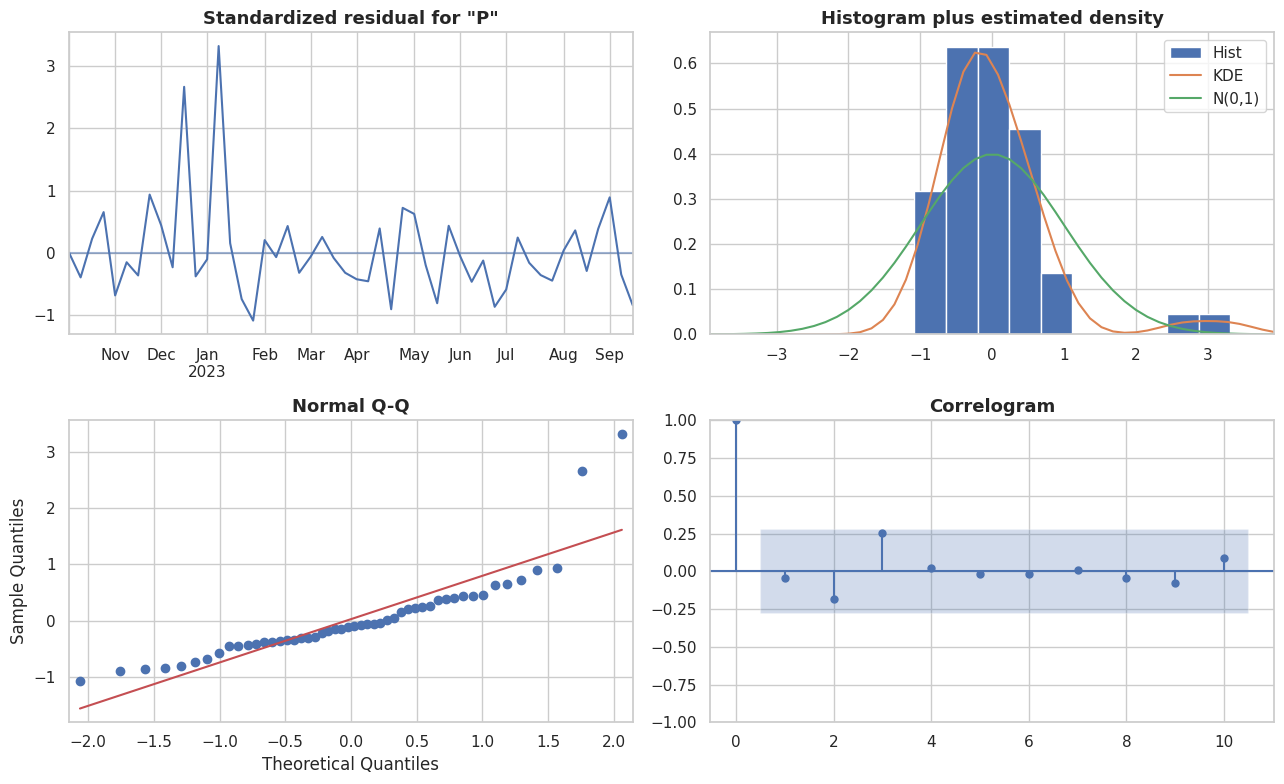

In [ ]:
# Diagnostik residual — residual yang baik seharusnya menyerupai white noise
model_sarima.plot_diagnostics(figsize=(13, 8))
plt.tight_layout()
plt.show()

### 7.3 Prophet

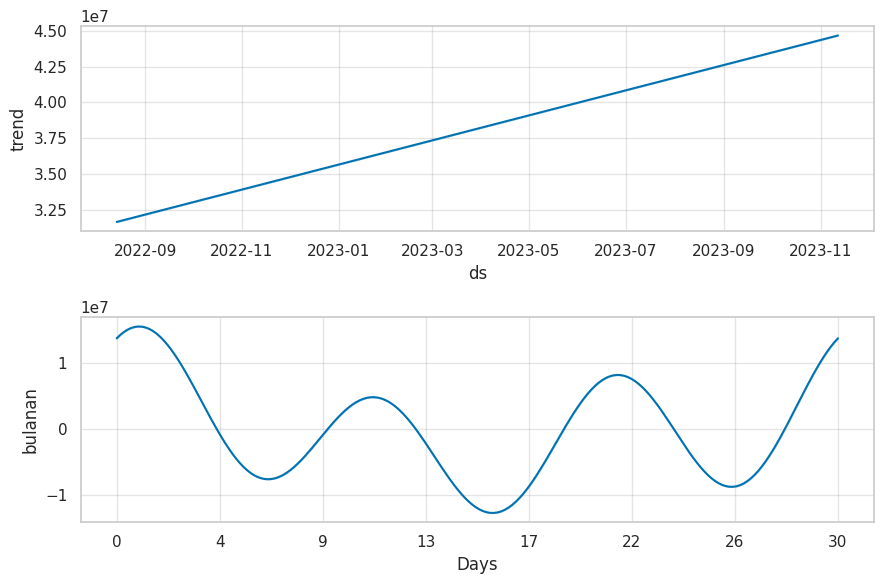

In [ ]:
from prophet import Prophet

# Prophet membutuhkan format kolom bernama 'ds' (tanggal) dan 'y' (nilai)
df_prophet = train.reset_index()
df_prophet.columns = ['ds', 'y']

model_prophet = Prophet(
    yearly_seasonality=False,   # data hanya ~1.3 tahun, belum cukup untuk musiman tahunan
    weekly_seasonality=False,   # sudah diagregasi mingguan
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    interval_width=0.80
)
model_prophet.add_seasonality(name='bulanan', period=30.5, fourier_order=3)
model_prophet.fit(df_prophet)

masa_depan = model_prophet.make_future_dataframe(periods=HORIZON, freq='W')
forecast_prophet = model_prophet.predict(masa_depan)

pred_prophet = forecast_prophet['yhat'].iloc[-HORIZON:].values
prediksi['Prophet'] = pred_prophet
hasil.append(evaluasi(test, pred_prophet, 'Prophet'))

fig = model_prophet.plot_components(forecast_prophet)
plt.tight_layout()
plt.show()

### 7.4 Random Forest dengan Fitur Lag

Pendekatan machine learning: masalah forecasting diubah menjadi masalah regresi biasa (*supervised learning*) dengan cara membuat fitur dari nilai-nilai masa lalu.

Ukuran X_train: (50, 11)
Ukuran X_test : (8, 11)


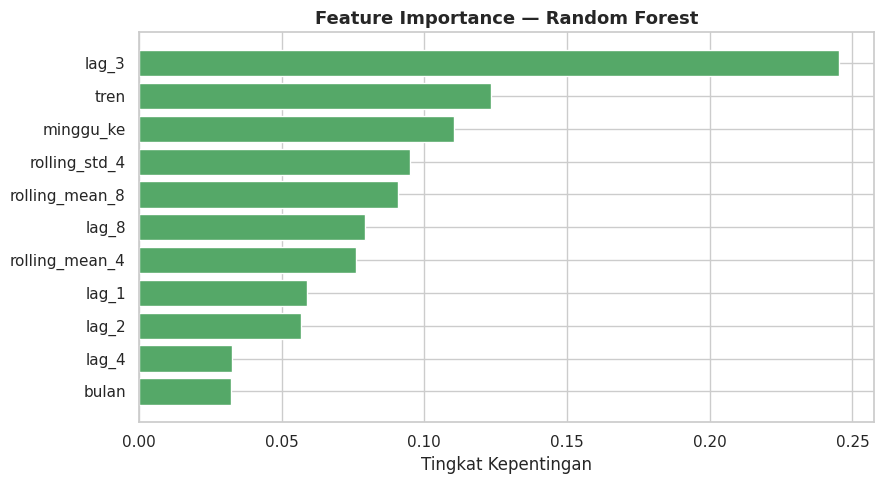

In [ ]:
from sklearn.ensemble import RandomForestRegressor

def buat_fitur(series, lags=(1, 2, 3, 4, 8)):
    """Ubah time series menjadi tabel fitur untuk supervised learning."""
    d = pd.DataFrame({'y': series})
    for lag in lags:
        d[f'lag_{lag}'] = d['y'].shift(lag)
    d['rolling_mean_4']  = d['y'].shift(1).rolling(4).mean()
    d['rolling_std_4']   = d['y'].shift(1).rolling(4).std()
    d['rolling_mean_8']  = d['y'].shift(1).rolling(8).mean()
    d['bulan']           = d.index.month
    d['minggu_ke']       = d.index.isocalendar().week.astype(int)
    d['tren']            = np.arange(len(d))
    return d

fitur_lengkap = buat_fitur(ts).dropna()

# Split kronologis mengikuti pembagian train/test sebelumnya
X = fitur_lengkap.drop(columns='y')
y = fitur_lengkap['y']
batas = fitur_lengkap.index <= train.index[-1]

X_train, y_train = X[batas], y[batas]
X_test,  y_test  = X[~batas], y[~batas]

print(f'Ukuran X_train: {X_train.shape}')
print(f'Ukuran X_test : {X_test.shape}')

model_rf = RandomForestRegressor(n_estimators=500, max_depth=8,
                                 min_samples_leaf=2, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)

prediksi['Random Forest'] = pred_rf
hasil.append(evaluasi(y_test, pred_rf, 'Random Forest'))

# Feature importance
kepentingan = pd.Series(model_rf.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(kepentingan.index, kepentingan.values, color='#55A868')
ax.set_title('Feature Importance — Random Forest')
ax.set_xlabel('Tingkat Kepentingan')
plt.tight_layout()
plt.show()

> **Catatan kejujuran metodologis:** Random Forest di sini dievaluasi dengan skema> *one-step-ahead* menggunakan nilai aktual sebagai lag. Dalam praktik nyata,> untuk meramal 8 minggu ke depan sekaligus, nilai aktual itu belum tersedia sehingga> model harus memakai prediksinya sendiri secara berulang (*recursive forecasting*),> yang biasanya menurunkan akurasi. Jadi angka RF di bawah cenderung **terlalu optimis**> dibanding SARIMA/Prophet yang meramal langsung 8 langkah ke depan.

### 7.5 Holt-Winters (Exponential Smoothing)
Metode klasik yang memberi bobot lebih besar pada observasi terbaru. Sering kalisangat kompetitif untuk deret pendek dan menjadi pembanding yang baik untuk SARIMA.

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

konfigurasi_hw = [
    ('Holt-Winters (add)',  dict(trend='add', seasonal='add', seasonal_periods=4)),
    ('Holt-Winters (tren teredam)', dict(trend='add', damped_trend=True, seasonal='add', seasonal_periods=4)),
    ('Simple Exp. Smoothing', dict(trend=None, seasonal=None)),
]

hasil_hw = []
for nama, cfg in konfigurasi_hw:
    try:
        m = ExponentialSmoothing(train, **cfg).fit()
        p = m.forecast(HORIZON).clip(lower=0)
        hasil_hw.append((nama, p, m.aic))
    except Exception as e:
        print(f'{nama} gagal: {e}')

# Pilih varian dengan AIC terendah agar tabel perbandingan tidak terlalu penuh
nama_hw, pred_hw, _ = min(hasil_hw, key=lambda x: x[2])
print(f'Varian Holt-Winters terpilih: {nama_hw}')

prediksi['Holt-Winters'] = pred_hw.values
hasil.append(evaluasi(test, pred_hw, nama_hw))
pd.DataFrame(hasil).tail(1)

Varian Holt-Winters terpilih: Simple Exp. Smoothing


,Model,MAE,RMSE,MAPE (%)
6,Simple Exp. Smoothing,"9,344,916.30","14,112,081.35",19.24


### 7.6 XGBoost dengan Fitur LagGradient boosting, umumnya lebih kuat dari Random Forest untuk data tabular. Menggunakan set fitur yang sama.

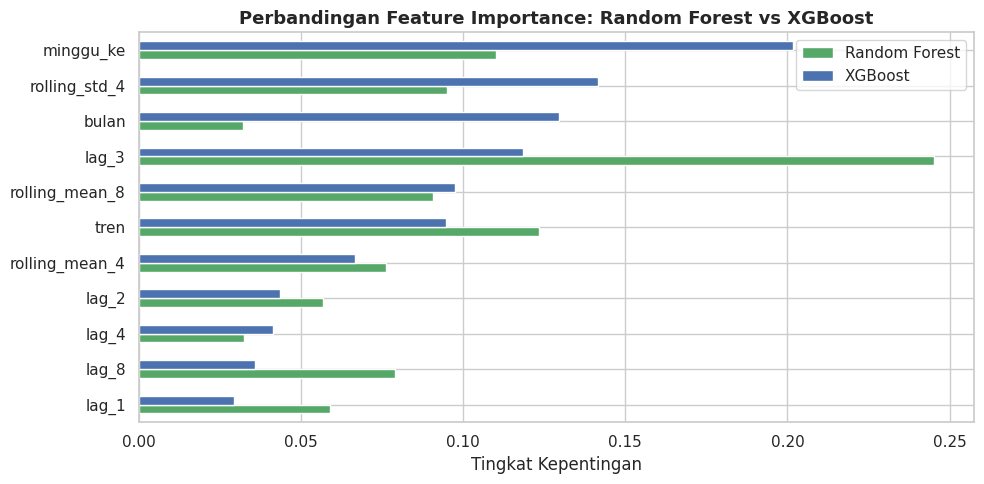

In [ ]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=400, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)
model_xgb.fit(X_train, y_train)
pred_xgb = model_xgb.predict(X_test).clip(min=0)

prediksi['XGBoost'] = pred_xgb
hasil.append(evaluasi(y_test, pred_xgb, 'XGBoost'))

# Bandingkan feature importance kedua model ML
imp = pd.DataFrame({
    'Random Forest': model_rf.feature_importances_,
    'XGBoost': model_xgb.feature_importances_
}, index=X.columns).sort_values('XGBoost')

fig, ax = plt.subplots(figsize=(10, 5))
imp.plot(kind='barh', ax=ax, color=['#55A868', '#4C72B0'])
ax.set_title('Perbandingan Feature Importance: Random Forest vs XGBoost')
ax.set_xlabel('Tingkat Kepentingan')
plt.tight_layout()
plt.show()

### 7.7 Ensemble (Rata-rata Beberapa Model)
Menggabungkan prediksi beberapa model sering menghasilkan akurasi lebih baik danlebih stabil daripada mengandalkan satu model saja, karena kesalahan tiap model cenderung saling meniadakan.

In [ ]:
# Ensemble sederhana: rata-rata dari model statistik (bukan ML, agar setara
# dalam hal skema peramalan multi-langkah)
anggota_ensemble = ['SARIMA', 'Prophet', 'Holt-Winters']
tersedia = [m for m in anggota_ensemble if m in prediksi]
print(f'Anggota ensemble: {", ".join(tersedia)}')

pred_ensemble = np.mean([np.asarray(prediksi[m], dtype=float) for m in tersedia], axis=0)
prediksi['Ensemble'] = pred_ensemble
hasil.append(evaluasi(test, pred_ensemble, f'Ensemble ({len(tersedia)} model)'))

pd.DataFrame(hasil).sort_values('MAPE (%)').style.format({
    'MAE': 'Rp {:,.0f}', 'RMSE': 'Rp {:,.0f}', 'MAPE (%)': '{:.2f}'
})

Anggota ensemble: SARIMA, Prophet, Holt-Winters


,Model,MAE,RMSE,MAPE (%)
6,Simple Exp. Smoothing,"Rp 9,344,916","Rp 14,112,081",19.24
8,Ensemble (3 model),"Rp 9,679,473","Rp 12,618,624",22.96
4,Prophet,"Rp 11,172,305","Rp 14,068,759",24.57
7,XGBoost,"Rp 10,035,626","Rp 12,462,014",25.11
5,Random Forest,"Rp 10,565,111","Rp 14,661,521",27.36
0,Naive,"Rp 16,513,125","Rp 20,965,210",35.32
2,Moving Average (4),"Rp 13,604,844","Rp 15,116,828",36.19
3,"SARIMA(0, 1, 2)x(1, 0, 1, 4)","Rp 14,407,185","Rp 15,613,752",38.72
1,Seasonal Naive,"Rp 27,424,375","Rp 31,121,121",71.10


## 8. Perbandingan Model & Prediksi Akhir

In [ ]:
perbandingan = pd.DataFrame(hasil).sort_values('MAPE (%)').reset_index(drop=True)
perbandingan.style.format({
    'MAE': 'Rp {:,.0f}', 'RMSE': 'Rp {:,.0f}', 'MAPE (%)': '{:.2f}'
}).background_gradient(subset=['MAPE (%)'], cmap='RdYlGn_r')

,Model,MAE,RMSE,MAPE (%)
0,Simple Exp. Smoothing,"Rp 9,344,916","Rp 14,112,081",19.24
1,Ensemble (3 model),"Rp 9,679,473","Rp 12,618,624",22.96
2,Prophet,"Rp 11,172,305","Rp 14,068,759",24.57
3,XGBoost,"Rp 10,035,626","Rp 12,462,014",25.11
4,Random Forest,"Rp 10,565,111","Rp 14,661,521",27.36
5,Naive,"Rp 16,513,125","Rp 20,965,210",35.32
6,Moving Average (4),"Rp 13,604,844","Rp 15,116,828",36.19
7,"SARIMA(0, 1, 2)x(1, 0, 1, 4)","Rp 14,407,185","Rp 15,613,752",38.72
8,Seasonal Naive,"Rp 27,424,375","Rp 31,121,121",71.10


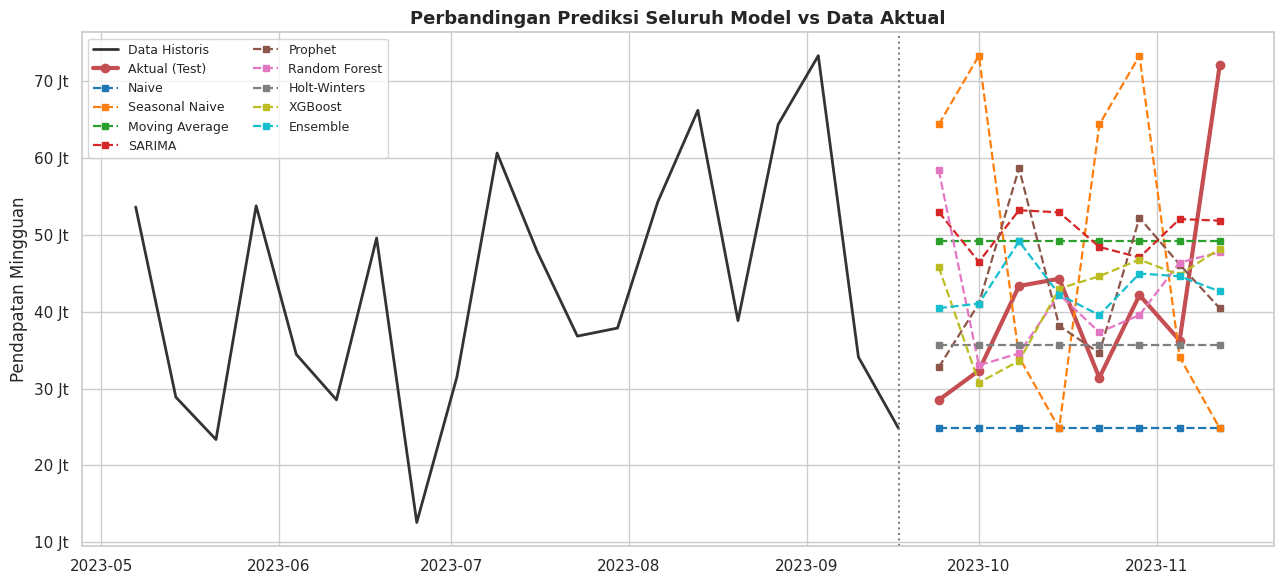

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(train.index[-20:], train.values[-20:], label='Data Historis',
        color='#333333', lw=2)
ax.plot(test.index, test.values, label='Aktual (Test)',
        color='#C44E52', lw=3, marker='o')

warna = plt.cm.tab10(np.linspace(0, 1, len(prediksi)))
for (nama, p), c in zip(prediksi.items(), warna):
    ax.plot(test.index, p, label=nama, ls='--', lw=1.6, marker='s', ms=4, color=c)

ax.axvline(train.index[-1], ls=':', color='gray')
ax.set_title('Perbandingan Prediksi Seluruh Model vs Data Aktual')
ax.set_ylabel('Pendapatan Mingguan')
ax.yaxis.set_major_formatter(RP)
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

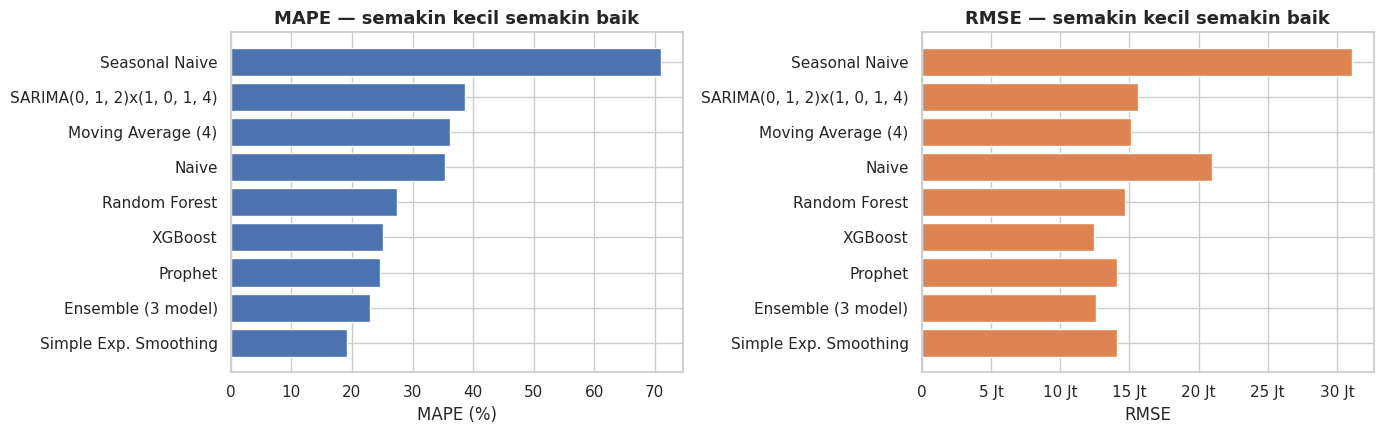

In [ ]:
# Visualisasi metrik
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].barh(perbandingan['Model'], perbandingan['MAPE (%)'], color='#4C72B0')
axes[0].set_title('MAPE — semakin kecil semakin baik')
axes[0].set_xlabel('MAPE (%)')

axes[1].barh(perbandingan['Model'], perbandingan['RMSE'], color='#DD8452')
axes[1].set_title('RMSE — semakin kecil semakin baik')
axes[1].set_xlabel('RMSE')
axes[1].xaxis.set_major_formatter(RP)

plt.tight_layout()
plt.show()

### 8.1 Apakah model canggih benar-benar mengalahkan baseline?
Pertanyaan ini wajib dijawab sebelum merekomendasikan model apa pun. Model rumit yang kalah dari "tebak pakai nilai minggu lalu" tidak layak dipakai di produksi.

In [ ]:
mape_naive = perbandingan.loc[perbandingan['Model'] == 'Naive', 'MAPE (%)'].iloc[0]
perbandingan['vs Naive'] = perbandingan['MAPE (%)'].apply(
    lambda m: f'{(mape_naive - m) / mape_naive * 100:+.1f}% lebih baik' if m < mape_naive
              else f'{(m - mape_naive) / mape_naive * 100:.1f}% lebih buruk'
)

print('Perbandingan setiap model terhadap baseline Naive:\n')
display(perbandingan[['Model', 'MAPE (%)', 'vs Naive']]
        .style.format({'MAPE (%)': '{:.2f}'}))

menang = perbandingan[perbandingan['MAPE (%)'] < mape_naive]
print(f'\n{len(menang)} dari {len(perbandingan)} model berhasil mengalahkan baseline Naive.')
if len(menang) == 0:
    print('PERINGATAN: tidak ada model yang mengalahkan baseline. '
          'Gunakan rata-rata bergerak sederhana saja, dan pertimbangkan bahwa '
          'data ini mungkin terlalu acak untuk diramalkan dengan andal.')

Perbandingan setiap model terhadap baseline Naive:



,Model,MAPE (%),vs Naive
0,Simple Exp. Smoothing,19.24,+45.5% lebih baik
1,Ensemble (3 model),22.96,+35.0% lebih baik
2,Prophet,24.57,+30.4% lebih baik
3,XGBoost,25.11,+28.9% lebih baik
4,Random Forest,27.36,+22.5% lebih baik
5,Naive,35.32,0.0% lebih buruk
6,Moving Average (4),36.19,2.5% lebih buruk
7,"SARIMA(0, 1, 2)x(1, 0, 1, 4)",38.72,9.6% lebih buruk
8,Seasonal Naive,71.10,101.3% lebih buruk



5 dari 9 model berhasil mengalahkan baseline Naive.


### 8.2 Prediksi 8 minggu ke depan (dilatih ulang pada seluruh data)
Untuk peramalan final, model dilatih ulang menggunakan **seluruh data** yang tersedia(termasuk periode test), karena data terbaru paling relevan untuk meramal ke depan.

In [ ]:
model_final = SARIMAX(ts, order=best_order, seasonal_order=best_seasonal,
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

hasil_forecast = model_final.get_forecast(steps=HORIZON)
nilai_forecast = hasil_forecast.predicted_mean
interval       = hasil_forecast.conf_int(alpha=0.20)   # interval kepercayaan 80%

tabel_forecast = pd.DataFrame({
    'Minggu Berakhir': nilai_forecast.index.strftime('%d %b %Y'),
    'Prediksi': nilai_forecast.values,
    'Batas Bawah': interval.iloc[:, 0].values,
    'Batas Atas': interval.iloc[:, 1].values,
}).reset_index(drop=True)
tabel_forecast.index = tabel_forecast.index + 1

display(tabel_forecast.style.format({
    'Prediksi': 'Rp {:,.0f}', 'Batas Bawah': 'Rp {:,.0f}', 'Batas Atas': 'Rp {:,.0f}'
}))

print(f'\nTotal prediksi pendapatan {HORIZON} minggu ke depan: '
      f'Rp {nilai_forecast.sum():,.0f}')
print(f'Rata-rata per minggu: Rp {nilai_forecast.mean():,.0f}')

,Minggu Berakhir,Prediksi,Batas Bawah,Batas Atas
1,19 Nov 2023,"Rp 41,662,183","Rp 5,317,745","Rp 78,006,622"
2,26 Nov 2023,"Rp 40,868,925","Rp 3,459,488","Rp 78,278,361"
3,03 Dec 2023,"Rp 46,308,920","Rp 8,775,753","Rp 83,842,087"
4,10 Dec 2023,"Rp 41,004,883","Rp 3,348,391","Rp 78,661,375"
5,17 Dec 2023,"Rp 45,317,750","Rp 6,768,761","Rp 83,866,738"
6,24 Dec 2023,"Rp 41,588,099","Rp 2,996,829","Rp 80,179,370"
7,31 Dec 2023,"Rp 45,369,255","Rp 6,690,797","Rp 84,047,713"
8,07 Jan 2024,"Rp 41,682,599","Rp 2,917,148","Rp 80,448,051"



Total prediksi pendapatan 8 minggu ke depan: Rp 343,802,614
Rata-rata per minggu: Rp 42,975,327


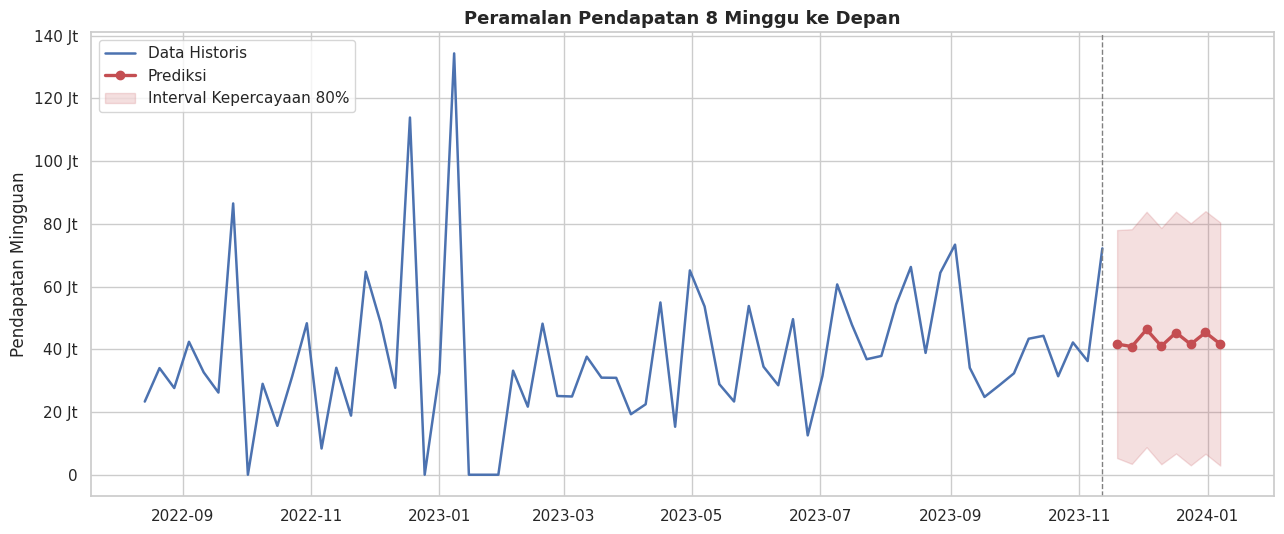

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.plot(ts.index, ts.values, label='Data Historis', color='#4C72B0', lw=1.8)
ax.plot(nilai_forecast.index, nilai_forecast.values,
        label='Prediksi', color='#C44E52', lw=2.4, marker='o')
ax.fill_between(nilai_forecast.index,
                interval.iloc[:, 0], interval.iloc[:, 1],
                color='#C44E52', alpha=0.18, label='Interval Kepercayaan 80%')
ax.axvline(ts.index[-1], ls='--', color='gray', lw=1)

ax.set_title(f'Peramalan Pendapatan {HORIZON} Minggu ke Depan')
ax.set_ylabel('Pendapatan Mingguan')
ax.yaxis.set_major_formatter(RP)
ax.legend()
plt.tight_layout()
plt.show()

### 8.3 Peramalan per kategori produk
Peramalan agregat berguna untuk perencanaan keuangan. Tapi untuk perencanaan**stok bahan baku**, perusahaan butuh peramalan per kategori.

Meramalkan kategori: Dupleks, Ivory, Craft, Foodpak



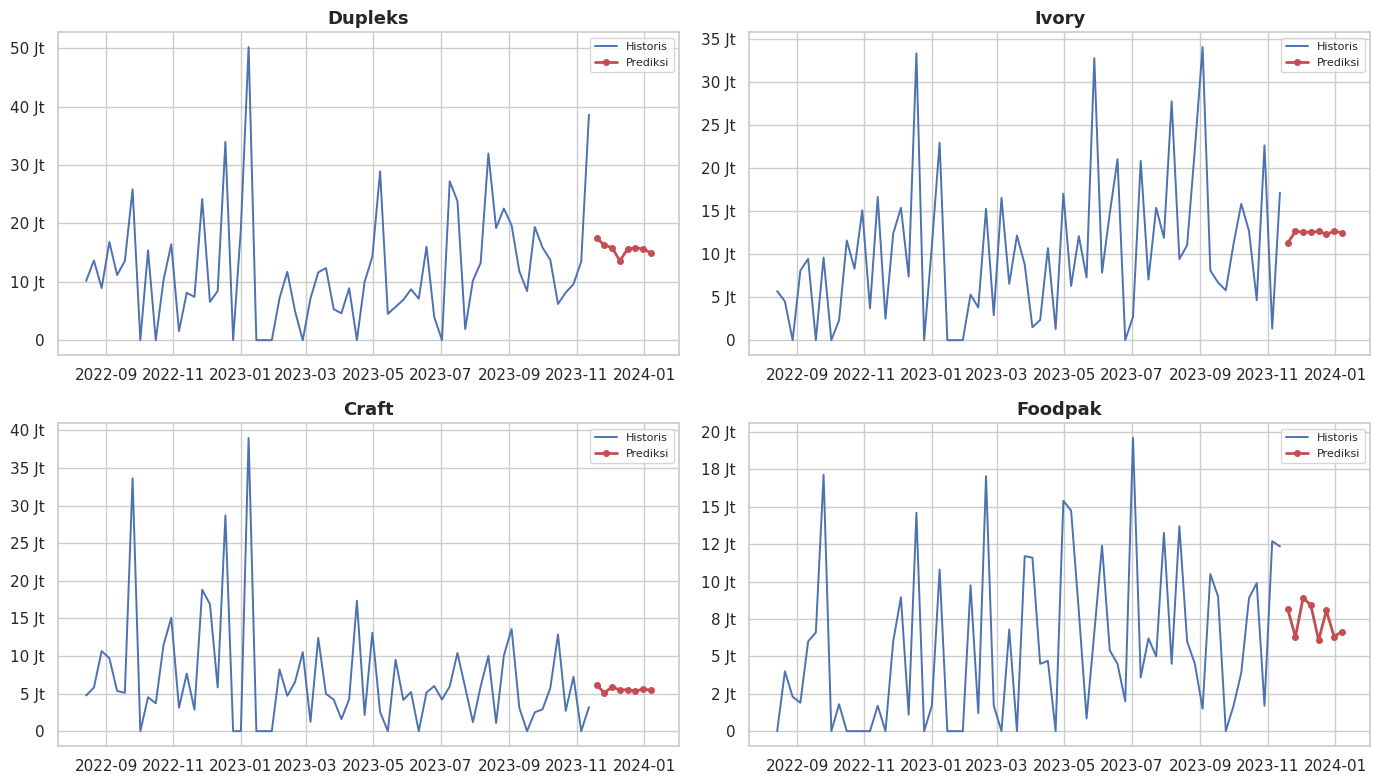

,Kategori,Rata2 Historis/Minggu,Prediksi Total 8 Minggu,Prediksi Rata2/Minggu
0,Dupleks,"Rp 12,064,621","Rp 125,115,767","Rp 15,639,471"
1,Ivory,"Rp 10,225,773","Rp 99,212,185","Rp 12,401,523"
2,Craft,"Rp 7,040,341","Rp 44,452,410","Rp 5,556,551"
3,Foodpak,"Rp 5,636,364","Rp 58,918,130","Rp 7,364,766"


In [ ]:
kategori_top = df.groupby('Kategori')['Total'].sum().nlargest(4).index.tolist()
print(f'Meramalkan kategori: {", ".join(kategori_top)}\n')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
ringkasan_kategori = []

for ax, kat in zip(axes.ravel(), kategori_top):
    sub = df[df['Kategori'] == kat].groupby('Tanggal')['Total'].sum()
    sub = sub.reindex(rentang_penuh, fill_value=0).resample('W').sum().iloc[1:-1]

    try:
        m = SARIMAX(sub, order=(1, 1, 1), seasonal_order=(1, 0, 1, 4),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        f = m.forecast(HORIZON)
        f = f.clip(lower=0)   # pendapatan tidak boleh negatif

        ax.plot(sub.index, sub.values, color='#4C72B0', lw=1.4, label='Historis')
        ax.plot(f.index, f.values, color='#C44E52', lw=2, marker='o', ms=4, label='Prediksi')
        ax.set_title(f'{kat}')
        ax.yaxis.set_major_formatter(RP)
        ax.legend(fontsize=8)

        ringkasan_kategori.append({
            'Kategori': kat,
            'Rata2 Historis/Minggu': sub.mean(),
            'Prediksi Total 8 Minggu': f.sum(),
            'Prediksi Rata2/Minggu': f.mean()
        })
    except Exception as e:
        ax.text(0.5, 0.5, f'Gagal: {e}', ha='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()

pd.DataFrame(ringkasan_kategori).style.format({
    'Rata2 Historis/Minggu': 'Rp {:,.0f}',
    'Prediksi Total 8 Minggu': 'Rp {:,.0f}',
    'Prediksi Rata2/Minggu': 'Rp {:,.0f}'
})

## 9. Backtesting:
Rolling-Origin Cross-ValidationEvaluasi dengan **satu** pembagian train/test punya kelemahan serius: hasilnya bisa kebetulan bagus atau kebetulan jelek tergantung periode mana yang kebetulan jadi test set.

Dengan hanya 8 minggu uji, satu minggu anomali saja bisa mengubah kesimpulan. **Rolling-origin cross-validation** mengatasi ini dengan menguji model berulang kalipada beberapa titik waktu berbeda, lalu merata-ratakan hasilnya.
Inilah cara evaluasiforecasting yang benar.

```Fold 1: [=====train=====][test] Fold 2: [=======train=======][test]Fold 3: [=========train=========][test]...```

In [ ]:
def backtest_rolling(series, horizon=4, n_folds=6, min_train=36):
    """Rolling-origin CV: uji model pada beberapa titik potong waktu berbeda."""
    catatan = []
    titik_potong = range(len(series) - horizon * n_folds, len(series) - horizon + 1, horizon)

    for i, potong in enumerate(titik_potong, start=1):
        if potong < min_train:
            continue
        tr = series.iloc[:potong]
        te = series.iloc[potong:potong + horizon]
        if len(te) < horizon:
            break

        kandidat = {}

        # Baseline
        kandidat['Naive'] = np.repeat(tr.iloc[-1], horizon)
        kandidat['Moving Average (4)'] = np.repeat(tr.iloc[-4:].mean(), horizon)

        # SARIMA
        try:
            m = SARIMAX(tr, order=best_order, seasonal_order=best_seasonal,
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            kandidat['SARIMA'] = m.forecast(horizon).clip(lower=0).values
        except Exception:
            pass

        # Holt-Winters
        try:
            m = ExponentialSmoothing(tr, trend='add', seasonal='add', seasonal_periods=4).fit()
            kandidat['Holt-Winters'] = m.forecast(horizon).clip(lower=0).values
        except Exception:
            pass

        for nama, p in kandidat.items():
            m_eval = evaluasi(te, p, nama)
            m_eval.update({'Fold': i, 'Batas Train': series.index[potong - 1].date()})
            catatan.append(m_eval)

    return pd.DataFrame(catatan)

print('Menjalankan backtesting... (beberapa menit)\n')
bt = backtest_rolling(ts, horizon=4, n_folds=6)
print(f'Jumlah fold yang berhasil: {bt["Fold"].nunique()}')
bt.head(10)

Menjalankan backtesting... (beberapa menit)



/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/holtwinters/model.py:1065: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  res = self._optimize_parameters(res, use_brute, method, minimize_kwargs)


Jumlah fold yang berhasil: 6


,Model,MAE,RMSE,MAPE (%),Fold,Batas Train
0,Naive,"22,519,375.00","26,137,249.07",120.49,1,2023-05-28
1,Moving Average (4),"13,480,000.00","15,831,953.20",73.36,1,2023-05-28
2,SARIMA,"11,905,488.17","15,455,447.78",67.13,1,2023-05-28
3,Holt-Winters,"16,310,086.68","17,461,281.59",74.37,1,2023-05-28
4,Naive,"31,660,000.00","33,577,439.78",69.79,2,2023-06-25
5,Moving Average (4),"12,929,375.00","17,095,543.29",24.70,2,2023-06-25
6,SARIMA,"10,495,598.71","13,113,915.90",22.12,2,2023-06-25
7,Holt-Winters,"15,990,910.63","17,362,446.51",34.79,2,2023-06-25
8,Naive,"12,485,000.00","17,139,881.49",21.13,3,2023-07-23
9,Moving Average (4),"10,950,000.00","12,802,746.29",20.59,3,2023-07-23


,MAPE_rata2,MAPE_stdev,MAPE_terburuk,MAE_rata2,Jumlah_Fold
Model,,,,,
SARIMA,35.5%,18.6,67.1%,"Rp 13,159,118",6
Moving Average (4),37.7%,20.9,73.4%,"Rp 13,464,896",6
Holt-Winters,40.6%,17.3,74.4%,"Rp 15,697,826",6
Naive,51.4%,38.0,120.5%,"Rp 18,573,958",6


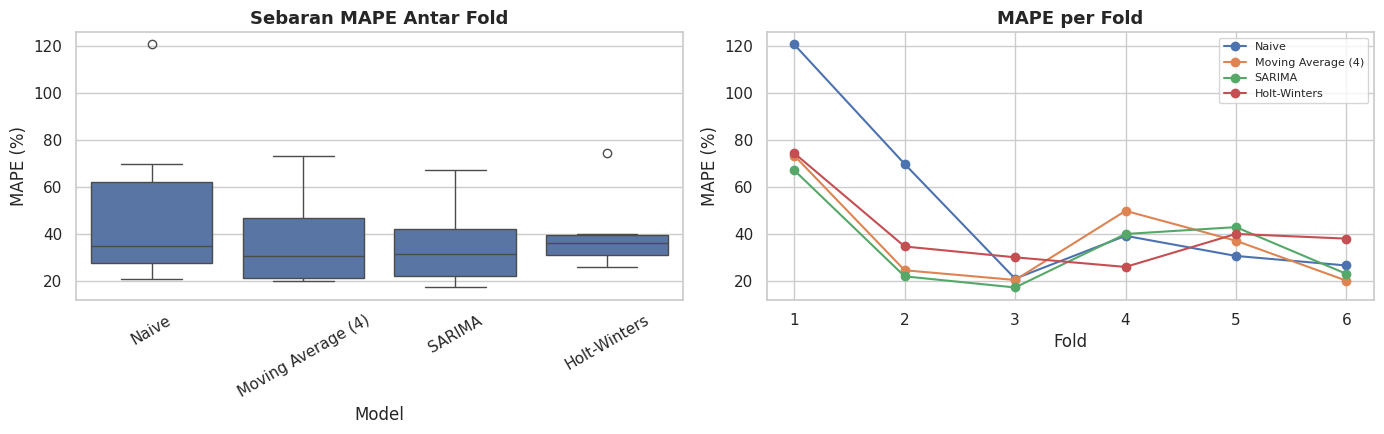

In [ ]:
ringkas_bt = bt.groupby('Model').agg(
    MAPE_rata2=('MAPE (%)', 'mean'),
    MAPE_stdev=('MAPE (%)', 'std'),
    MAPE_terburuk=('MAPE (%)', 'max'),
    MAE_rata2=('MAE', 'mean'),
    Jumlah_Fold=('MAPE (%)', 'count')
).sort_values('MAPE_rata2')

display(ringkas_bt.style.format({
    'MAPE_rata2': '{:.1f}%', 'MAPE_stdev': '{:.1f}',
    'MAPE_terburuk': '{:.1f}%', 'MAE_rata2': 'Rp {:,.0f}'
}).background_gradient(subset=['MAPE_rata2'], cmap='RdYlGn_r'))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.boxplot(data=bt, x='Model', y='MAPE (%)', ax=axes[0])
axes[0].set_title('Sebaran MAPE Antar Fold')
axes[0].tick_params(axis='x', rotation=30)

for model in bt['Model'].unique():
    sub = bt[bt['Model'] == model]
    axes[1].plot(sub['Fold'], sub['MAPE (%)'], marker='o', label=model)
axes[1].set_title('MAPE per Fold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('MAPE (%)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Perhatikan bahwa angka MAPE di backtesting biasanya **lebih tinggi** (lebih buruk) daripada hasil evaluasi satu kali di bagian 8.

 Itu normal dan justru menandakanevaluasi ini lebih jujur — satu pembagian train/test cenderung memberi kesanterlalu optimis.

 Perhatikan juga kolom **MAPE_stdev**. Model dengan rata-rata bagus tapi simpangan bakubesar berarti performanya tidak konsisten: kadang sangat akurat, kadang meleset jauh.

 Untuk keperluan perencanaan bisnis, model yang **stabil** sering lebih berhargadaripada model yang rata-ratanya sedikit lebih baik tapi tidak dapat diandalkan.

## 10. Analisis ABC-XYZ
Klasifikasi dua dimensi yang standar dipakai dalam manajemen persediaan:
- **ABC** — berdasarkan **nilai** kontribusi pendapatan (A = paling bernilai)
- **XYZ** — berdasarkan **prediktabilitas** permintaan (X = paling stabil/mudah diramal)

Kombinasinya menghasilkan strategi pengelolaan stok yang berbeda untuk tiap kelas.

In [ ]:
# Matriks produk x bulan untuk menghitung volatilitas permintaan
matriks = df.pivot_table(index='produk_bersih',
                         columns=df['Tanggal'].dt.to_period('M'),
                         values='Total', aggfunc='sum').fillna(0)

pendapatan_produk = matriks.sum(axis=1).sort_values(ascending=False)
kumulatif = pendapatan_produk.cumsum() / pendapatan_produk.sum()

# Klasifikasi ABC berdasarkan kontribusi kumulatif
kelas_abc = pd.cut(kumulatif, [0, 0.80, 0.95, 1.01], labels=['A', 'B', 'C'])

# Klasifikasi XYZ berdasarkan koefisien variasi antar bulan
cv_produk = (matriks.std(axis=1) / matriks.mean(axis=1).replace(0, np.nan)).fillna(99)
kelas_xyz = pd.cut(cv_produk, [-0.01, 0.5, 1.0, 999], labels=['X', 'Y', 'Z'])

klasifikasi = pd.DataFrame({
    'Pendapatan': pendapatan_produk,
    'CV': cv_produk,
    'ABC': kelas_abc,
    'XYZ': kelas_xyz
})
klasifikasi['Kelas'] = klasifikasi['ABC'].astype(str) + klasifikasi['XYZ'].astype(str)

print('Matriks silang ABC x XYZ (jumlah produk):')
display(pd.crosstab(klasifikasi['ABC'], klasifikasi['XYZ'], margins=True))

print('\nProduk kelas A (penyumbang 80% pendapatan):')
display(klasifikasi[klasifikasi['ABC'] == 'A']
        .sort_values('Pendapatan', ascending=False)
        .style.format({'Pendapatan': 'Rp {:,.0f}', 'CV': '{:.2f}'}))

Matriks silang ABC x XYZ (jumlah produk):


XYZ,X,Y,Z,All
ABC,,,,
A,2,6,4,12
B,0,2,20,22
C,0,0,53,53
All,2,8,77,87



Produk kelas A (penyumbang 80% pendapatan):


,Pendapatan,CV,ABC,XYZ,Kelas
produk_bersih,,,,,
DUPLEKS310,"Rp 432,590,000",0.47,A,X,AX
CRAFTLAMINASI290,"Rp 327,937,500",0.51,A,Y,AY
IVORY230,"Rp 235,306,000",0.31,A,X,AX
DUPLEKS350,"Rp 227,375,000",0.54,A,Y,AY
FOODPAKMATTE245,"Rp 156,100,000",0.90,A,Y,AY
IVORY270,"Rp 139,630,000",0.70,A,Y,AY
IVORY350,"Rp 119,700,000",1.42,A,Z,AZ
IVORY250,"Rp 91,100,000",0.76,A,Y,AY
FOODPAK260GLOSSY,"Rp 88,900,000",1.30,A,Z,AZ


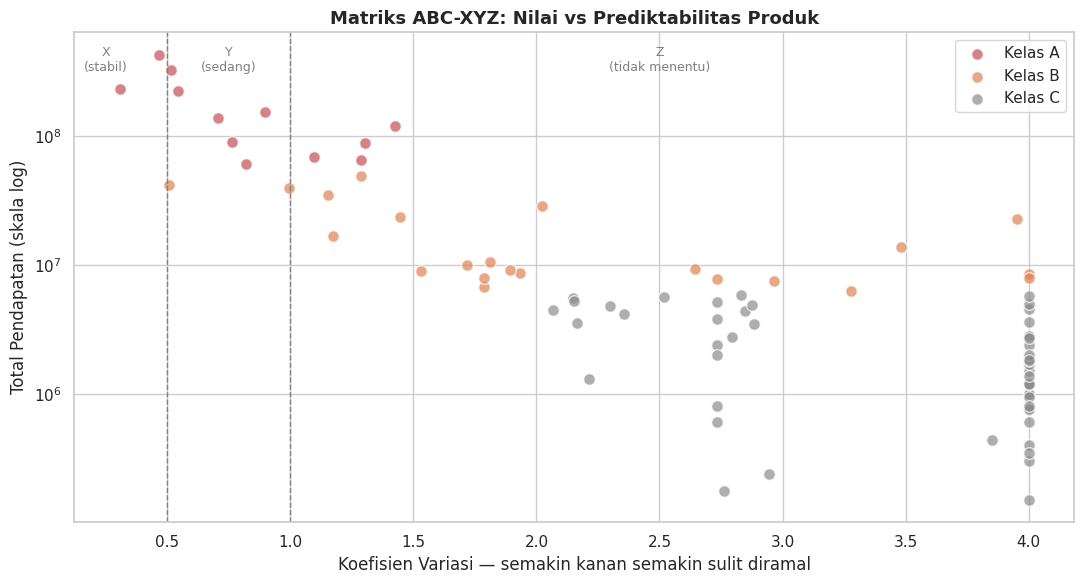

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

warna_kelas = {'A': '#C44E52', 'B': '#DD8452', 'C': '#8C8C8C'}
for kls, grup in klasifikasi.groupby('ABC', observed=True):
    ax.scatter(grup['CV'].clip(upper=5), grup['Pendapatan'],
               s=70, alpha=0.7, label=f'Kelas {kls}',
               color=warna_kelas.get(kls, 'gray'), edgecolors='white')

ax.axvline(0.5, ls='--', color='gray', lw=1)
ax.axvline(1.0, ls='--', color='gray', lw=1)
ax.set_yscale('log')
ax.set_xlabel('Koefisien Variasi — semakin kanan semakin sulit diramal')
ax.set_ylabel('Total Pendapatan (skala log)')
ax.set_title('Matriks ABC-XYZ: Nilai vs Prediktabilitas Produk')
ax.text(0.25, ax.get_ylim()[1] * 0.5, 'X\n(stabil)', ha='center', fontsize=9, color='gray')
ax.text(0.75, ax.get_ylim()[1] * 0.5, 'Y\n(sedang)', ha='center', fontsize=9, color='gray')
ax.text(2.5,  ax.get_ylim()[1] * 0.5, 'Z\n(tidak menentu)', ha='center', fontsize=9, color='gray')
ax.legend()
plt.tight_layout()
plt.show()

### Strategi berdasarkan kelas
| Kelas | Karakteristik | Strategi yang disarankan ||---|---|---

||**AX** | Bernilai tinggi, permintaan stabil | Stok otomatis, *safety stock* rendah, target layanan tertinggi. Paling layak diramalkan.

|| **AY** | Bernilai tinggi, cukup fluktuatif | Pantau ketat, *safety stock* sedang, review mingguan.

|| **AZ** | Bernilai tinggi, sangat tidak menentu | Kelola per order, hindari stok besar. Idealnya produksi berdasarkan pesanan.

|| **BX / BY** | Nilai menengah | Review berkala, aturan *reorder point* standar.

|| **CZ** | Nilai kecil, tidak menentu | Jangan distok. Produksi *make-to-order* saja. Pertimbangkan penghentian produk. |

Perhatikan berapa banyak produk yang masuk kelas **CZ** — ini kandidat untukrasionalisasi portofolio produk. Mengelola puluhan produk bernilai kecil dan tidakmenentu menimbulkan biaya kompleksitas yang sering tidak disadari.

## 11. Efek Kalender:
 Ramadan, Lebaran, dan Hari Libur Konteks Indonesia sangat relevan di sini. Siklus Ramadan–Lebaran menggeser pola bisnis secara signifikan, dan tanggalnya berubah setiap tahun (kalender Hijriah) sehingga tidak tertangkap oleh model musiman biasa.

In [ ]:
# Tanggal penting yang relevan dengan rentang data (Agu 2022 - Nov 2023)
RAMADAN_2023  = pd.date_range('2023-03-23', '2023-04-21')
LEBARAN_2023  = pd.date_range('2023-04-22', '2023-05-01')   # termasuk cuti bersama

LIBUR_NASIONAL = pd.to_datetime([
    '2022-08-17',  # Kemerdekaan RI
    '2022-10-08',  # Maulid Nabi
    '2022-12-25',  # Natal
    '2023-01-01',  # Tahun Baru
    '2023-01-22',  # Imlek
    '2023-03-22',  # Nyepi
    '2023-04-07',  # Wafat Isa Almasih
    '2023-05-01',  # Hari Buruh
    '2023-06-01',  # Pancasila
    '2023-06-29',  # Idul Adha
    '2023-08-17',  # Kemerdekaan RI
    '2023-09-28',  # Maulid Nabi
])

label = pd.Series('Hari Biasa', index=rentang_penuh)
label[rentang_penuh.isin(LIBUR_NASIONAL)] = 'Libur Nasional'
label[rentang_penuh.isin(RAMADAN_2023)]   = 'Ramadan'
label[rentang_penuh.isin(LEBARAN_2023)]   = 'Libur Lebaran'

efek_kalender = pd.DataFrame({
    'Rata2 Pendapatan Harian': ts_harian.groupby(label).mean(),
    'Total Pendapatan': ts_harian.groupby(label).sum(),
    'Jumlah Hari': ts_harian.groupby(label).size(),
    '% Hari Tanpa Transaksi': ts_harian.groupby(label).apply(lambda s: (s == 0).mean() * 100)
})

baseline_harian = ts_harian[label == 'Hari Biasa'].mean()
efek_kalender['Indeks vs Hari Biasa'] = (
    efek_kalender['Rata2 Pendapatan Harian'] / baseline_harian * 100
)

efek_kalender.style.format({
    'Rata2 Pendapatan Harian': 'Rp {:,.0f}',
    'Total Pendapatan': 'Rp {:,.0f}',
    '% Hari Tanpa Transaksi': '{:.1f}%',
    'Indeks vs Hari Biasa': '{:.0f}'
})

,Rata2 Pendapatan Harian,Total Pendapatan,Jumlah Hari,% Hari Tanpa Transaksi,Indeks vs Hari Biasa
Hari Biasa,"Rp 5,440,954","Rp 2,274,318,876",418,39.5%,100
Libur Lebaran,"Rp 6,859,000","Rp 68,590,000",10,40.0%,126
Libur Nasional,"Rp 4,879,500","Rp 48,795,000",10,50.0%,90
Ramadan,"Rp 4,413,535","Rp 132,406,050",30,33.3%,81


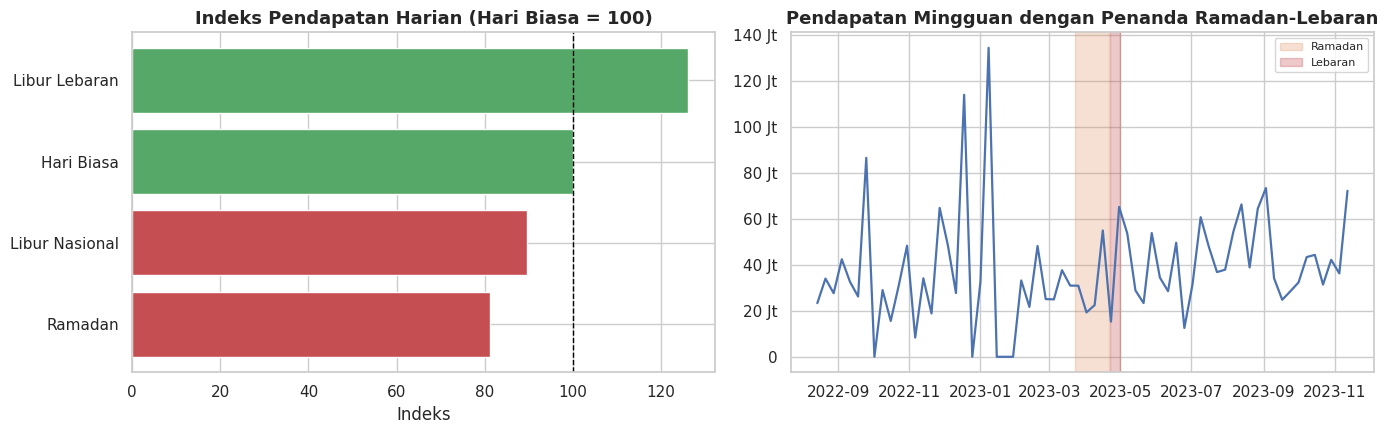

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

urut = efek_kalender.sort_values('Indeks vs Hari Biasa')
warna = ['#C44E52' if v < 100 else '#55A868' for v in urut['Indeks vs Hari Biasa']]
axes[0].barh(urut.index, urut['Indeks vs Hari Biasa'], color=warna)
axes[0].axvline(100, ls='--', color='black', lw=1)
axes[0].set_title('Indeks Pendapatan Harian (Hari Biasa = 100)')
axes[0].set_xlabel('Indeks')

# Sorot periode Ramadan-Lebaran pada deret mingguan
axes[1].plot(ts.index, ts.values, color='#4C72B0', lw=1.6)
axes[1].axvspan(RAMADAN_2023[0], RAMADAN_2023[-1], alpha=0.25, color='#DD8452', label='Ramadan')
axes[1].axvspan(LEBARAN_2023[0], LEBARAN_2023[-1], alpha=0.30, color='#C44E52', label='Lebaran')
axes[1].set_title('Pendapatan Mingguan dengan Penanda Ramadan-Lebaran')
axes[1].yaxis.set_major_formatter(RP)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

> **Peringatan tafsir:** rentang data hanya mencakup **satu** siklus Ramadan-Lebaran.> Satu observasi tidak cukup untuk menyimpulkan adanya pola musiman yang berulang —> perbedaan yang terlihat bisa saja kebetulan atau disebabkan faktor lain di periode> yang sama. Temuan ini layak dicatat sebagai **hipotesis untuk diverifikasi**> ketika data tahun berikutnya tersedia, bukan sebagai fakta mapan.>> Menyebutkan keterbatasan ini secara eksplisit justru lebih meyakinkan daripada> menyajikan angkanya seolah-olah sudah pasti.

## 12. Deteksi Anomali
Mengidentifikasi minggu-minggu dengan penjualan tidak normal. Berguna untuk investigasi: apakah ada order jumbo, kesalahan pencatatan, atau gangguan operasional?

Minggu anomali terdeteksi: 1 dari 66



,Pendapatan,Z-score (rolling),Jenis
2022-09-25 00:00:00,"Rp 86,500,000",2.15,Lonjakan


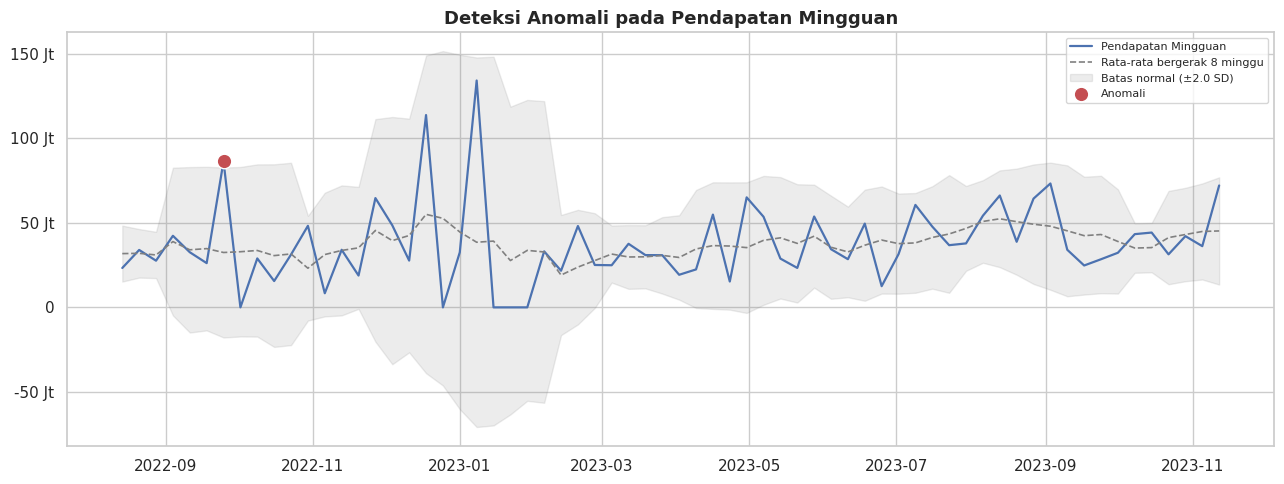

In [ ]:
# Metode 1: Z-score terhadap rata-rata bergerak
jendela = 8
rata_gerak = ts.rolling(jendela, center=True, min_periods=3).mean()
std_gerak  = ts.rolling(jendela, center=True, min_periods=3).std()
zscore = (ts - rata_gerak) / std_gerak

# Metode 2: Residual dari model SARIMA
residual = model_final.resid
z_residual = (residual - residual.mean()) / residual.std()

AMBANG = 2.0
anomali = pd.DataFrame({
    'Pendapatan': ts,
    'Z-score (rolling)': zscore,
    'Z-score (residual SARIMA)': z_residual
})
anomali['Anomali'] = (anomali['Z-score (rolling)'].abs() > AMBANG)
anomali['Jenis'] = np.where(anomali['Z-score (rolling)'] > AMBANG, 'Lonjakan',
                   np.where(anomali['Z-score (rolling)'] < -AMBANG, 'Penurunan', '-'))

terdeteksi = anomali[anomali['Anomali']]
print(f'Minggu anomali terdeteksi: {len(terdeteksi)} dari {len(ts)}\n')
display(terdeteksi[['Pendapatan', 'Z-score (rolling)', 'Jenis']]
        .style.format({'Pendapatan': 'Rp {:,.0f}', 'Z-score (rolling)': '{:.2f}'}))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ts.index, ts.values, color='#4C72B0', lw=1.6, label='Pendapatan Mingguan')
ax.plot(rata_gerak.index, rata_gerak.values, color='gray', ls='--', lw=1.2,
        label=f'Rata-rata bergerak {jendela} minggu')
ax.fill_between(ts.index,
                rata_gerak - AMBANG * std_gerak,
                rata_gerak + AMBANG * std_gerak,
                alpha=0.15, color='gray', label=f'Batas normal (±{AMBANG} SD)')
if len(terdeteksi) > 0:
    ax.scatter(terdeteksi.index, terdeteksi['Pendapatan'],
               color='#C44E52', s=110, zorder=5, label='Anomali', edgecolors='white')
ax.set_title('Deteksi Anomali pada Pendapatan Mingguan')
ax.yaxis.set_major_formatter(RP)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Telusuri transaksi penyusun minggu anomali
if len(terdeteksi) > 0:
    for tanggal in terdeteksi.index[:3]:
        awal = tanggal - pd.Timedelta(days=6)
        rinci = df[(df['Tanggal'] >= awal) & (df['Tanggal'] <= tanggal)]
        print(f'--- Minggu berakhir {tanggal:%d %b %Y} '
              f'| Total: Rp {rinci["Total"].sum():,.0f} '
              f'| {len(rinci)} transaksi ---')
        display(rinci.nlargest(5, 'Total')[
            ['Tanggal', 'Jenis Produk', 'Jumlah Order', 'Harga', 'Total']])
        print()
else:
    print('Tidak ada anomali yang terdeteksi pada ambang batas ini.')

--- Minggu berakhir 25 Sep 2022 | Total: Rp 86,500,000 | 35 transaksi ---


,Tanggal,Jenis Produk,Jumlah Order,Harga,Total
121,2022-09-24,Foodpak260Glossy,5000,1450,7250000
97,2022-09-19,CraftLaminasi290,4000,1700,6800000
89,2022-09-19,CraftLaminasi290,5000,1200,6000000
100,2022-09-19,CraftLaminasi290,3000,1700,5100000
96,2022-09-19,Foodpak260Glossy,2000,2300,4600000


## 13. Rekonsiliasi
Hierarkis Masalah praktis yang sering diabaikan: kalau kita meramal total penjualan **dan** meramal tiap kategori secara terpisah, hasilnya hampir pasti **tidak akan konsisten** —jumlah forecast kategori tidak sama dengan forecast total.Ini membingungkan bagi pengguna bisnis. Rekonsiliasi hierarkis menyelesaikannya.

In [ ]:
# Bangun struktur hierarki: Total = jumlah seluruh kategori
kat_mingguan = (df.groupby(['Kategori', pd.Grouper(key='Tanggal', freq='W')])['Total']
                  .sum().unstack(0).reindex(ts.index).fillna(0))

print(f'Jumlah kategori (level bawah): {kat_mingguan.shape[1]}')
print(f'Verifikasi: total kategori == total agregat? '
      f'{np.isclose(kat_mingguan.sum(axis=1).sum(), ts.sum())}')

# Ramal setiap kategori secara independen (pendekatan bottom-up)
forecast_kategori = {}
for kat in kat_mingguan.columns:
    seri = kat_mingguan[kat]
    if seri.sum() == 0:
        forecast_kategori[kat] = np.zeros(HORIZON)
        continue
    try:
        m = SARIMAX(seri, order=(1, 1, 1), seasonal_order=(1, 0, 1, 4),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        forecast_kategori[kat] = m.forecast(HORIZON).clip(lower=0).values
    except Exception:
        forecast_kategori[kat] = np.repeat(seri.iloc[-4:].mean(), HORIZON)

fc_kat = pd.DataFrame(forecast_kategori, index=nilai_forecast.index)

bottom_up = fc_kat.sum(axis=1)              # jumlah forecast kategori
top_down  = nilai_forecast                   # forecast total langsung

banding = pd.DataFrame({
    'Forecast Total (langsung)': top_down,
    'Jumlah Forecast Kategori': bottom_up,
    'Selisih': top_down - bottom_up,
    'Selisih (%)': (top_down - bottom_up) / top_down * 100
})
display(banding.style.format({
    'Forecast Total (langsung)': 'Rp {:,.0f}',
    'Jumlah Forecast Kategori': 'Rp {:,.0f}',
    'Selisih': 'Rp {:,.0f}', 'Selisih (%)': '{:.1f}%'
}))

print(f'\nRata-rata ketidakkonsistenan: {banding["Selisih (%)"].abs().mean():.1f}%')
print('Inilah masalah yang perlu direkonsiliasi.')

Jumlah kategori (level bawah): 10
Verifikasi: total kategori == total agregat? True


,Forecast Total (langsung),Jumlah Forecast Kategori,Selisih,Selisih (%)
2023-11-19 00:00:00,"Rp 41,662,183","Rp 52,515,155","Rp -10,852,972",-26.0%
2023-11-26 00:00:00,"Rp 40,868,925","Rp 42,593,581","Rp -1,724,656",-4.2%
2023-12-03 00:00:00,"Rp 46,308,920","Rp 62,391,482","Rp -16,082,562",-34.7%
2023-12-10 00:00:00,"Rp 41,004,883","Rp 43,320,911","Rp -2,316,028",-5.6%
2023-12-17 00:00:00,"Rp 45,317,750","Rp 57,454,343","Rp -12,136,593",-26.8%
2023-12-24 00:00:00,"Rp 41,588,099","Rp 45,264,182","Rp -3,676,083",-8.8%
2023-12-31 00:00:00,"Rp 45,369,255","Rp 76,832,436","Rp -31,463,181",-69.3%
2024-01-07 00:00:00,"Rp 41,682,599","Rp 47,033,275","Rp -5,350,675",-12.8%



Rata-rata ketidakkonsistenan: 23.6%
Inilah masalah yang perlu direkonsiliasi.


Verifikasi setelah rekonsiliasi:
  Selisih maksimum: Rp 0.00  (idealnya ~0)



,Dupleks,Ivory,Craft,Foodpak,TOTAL
19 Nov 2023,"Rp 13,863,602","Rp 8,954,243","Rp 4,876,515","Rp 6,482,851","Rp 41,662,183"
26 Nov 2023,"Rp 15,600,988","Rp 12,149,409","Rp 4,874,817","Rp 6,040,787","Rp 40,868,925"
03 Dec 2023,"Rp 11,742,881","Rp 9,331,397","Rp 4,389,662","Rp 6,624,553","Rp 46,308,920"
10 Dec 2023,"Rp 12,847,620","Rp 11,876,641","Rp 5,148,510","Rp 7,954,779","Rp 41,004,883"
17 Dec 2023,"Rp 12,343,248","Rp 9,969,475","Rp 4,356,493","Rp 4,792,961","Rp 45,317,750"
24 Dec 2023,"Rp 14,491,739","Rp 11,338,493","Rp 4,883,338","Rp 7,411,384","Rp 41,588,099"
31 Dec 2023,"Rp 9,245,451","Rp 7,466,944","Rp 3,311,959","Rp 3,730,598","Rp 45,369,255"
07 Jan 2024,"Rp 13,212,309","Rp 11,094,236","Rp 4,807,490","Rp 5,902,981","Rp 41,682,599"


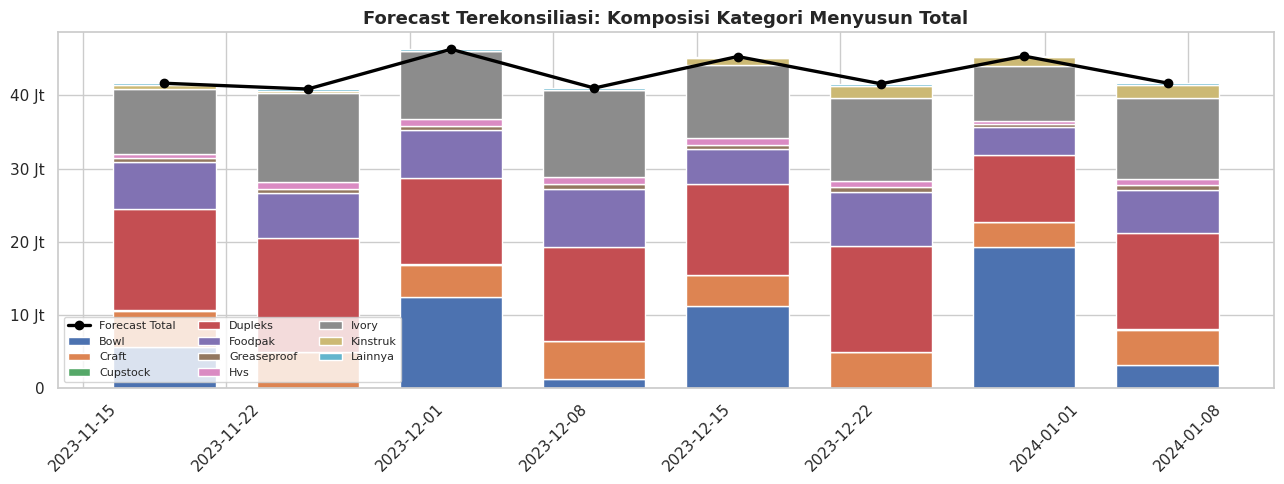

In [ ]:
# Rekonsiliasi metode proporsional: sesuaikan forecast kategori agar
# jumlahnya tepat sama dengan forecast total
proporsi = fc_kat.div(fc_kat.sum(axis=1), axis=0).fillna(0)
fc_rekonsiliasi = proporsi.mul(top_down, axis=0)

print('Verifikasi setelah rekonsiliasi:')
selisih_akhir = (fc_rekonsiliasi.sum(axis=1) - top_down).abs().max()
print(f'  Selisih maksimum: Rp {selisih_akhir:,.2f}  (idealnya ~0)\n')

tampil = fc_rekonsiliasi[kategori_top].copy()
tampil['TOTAL'] = fc_rekonsiliasi.sum(axis=1)
tampil.index = tampil.index.strftime('%d %b %Y')
display(tampil.style.format('Rp {:,.0f}'))

fig, ax = plt.subplots(figsize=(13, 5))
bawah = np.zeros(len(fc_rekonsiliasi))
for kat in fc_rekonsiliasi.columns:
    nilai = fc_rekonsiliasi[kat].values
    if nilai.sum() > 0:
        ax.bar(fc_rekonsiliasi.index, nilai, bottom=bawah, label=kat, width=5)
        bawah += nilai
ax.plot(top_down.index, top_down.values, color='black', lw=2.4,
        marker='o', label='Forecast Total', zorder=5)
ax.set_title('Forecast Terekonsiliasi: Komposisi Kategori Menyusun Total')
ax.yaxis.set_major_formatter(RP)
ax.legend(ncol=3, fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Manfaat praktisnya:** sekarang tim keuangan dan tim produksi memakai angka yang konsisten. Forecast total untuk proyeksi arus kas, dan rincian per kategori untukperencanaan bahan baku — keduanya saling cocok, tidak saling bertentangan.

## 14. Export Hasil
Menyimpan seluruh output analisis ke file Excel agar bisa dibagikan ke pihakyang tidak memakai Python.

In [ ]:
NAMA_OUTPUT = 'hasil_analisis_penjualan.xlsx'

with pd.ExcelWriter(NAMA_OUTPUT, engine='openpyxl') as writer:
    # Data bersih
    kolom_simpan = ['Tanggal', 'Jenis Produk', 'produk_bersih', 'Kategori',
                    'Gramatur', 'Jumlah Order', 'Harga', 'Total', 'is_outlier']
    df[kolom_simpan].to_excel(writer, sheet_name='Data Bersih', index=False)

    # Ringkasan bulanan & kategori
    bulanan.to_excel(writer, sheet_name='Ringkasan Bulanan')
    ringkas.to_excel(writer, sheet_name='Ringkasan Kategori')

    # Time series mingguan
    ts.to_frame('Pendapatan').to_excel(writer, sheet_name='Time Series Mingguan')

    # Hasil model
    perbandingan.to_excel(writer, sheet_name='Perbandingan Model', index=False)
    ringkas_bt.to_excel(writer, sheet_name='Hasil Backtesting')

    # Forecast
    tabel_forecast.to_excel(writer, sheet_name='Forecast Total', index=False)
    fc_rekonsiliasi.to_excel(writer, sheet_name='Forecast per Kategori')

    # Klasifikasi produk
    klasifikasi.to_excel(writer, sheet_name='Klasifikasi ABC-XYZ')

    # Anomali & kalender
    anomali[anomali['Anomali']].to_excel(writer, sheet_name='Anomali')
    efek_kalender.to_excel(writer, sheet_name='Efek Kalender')

print(f'Berhasil disimpan: {NAMA_OUTPUT}')
print('Sheet yang dibuat: Data Bersih, Ringkasan Bulanan, Ringkasan Kategori,')
print('  Time Series Mingguan, Perbandingan Model, Hasil Backtesting,')
print('  Forecast Total, Forecast per Kategori, Klasifikasi ABC-XYZ,')
print('  Anomali, Efek Kalender')

Berhasil disimpan: hasil_analisis_penjualan.xlsx
Sheet yang dibuat: Data Bersih, Ringkasan Bulanan, Ringkasan Kategori,
  Time Series Mingguan, Perbandingan Model, Hasil Backtesting,
  Forecast Total, Forecast per Kategori, Klasifikasi ABC-XYZ,
  Anomali, Efek Kalender


In [ ]:
# Unduh file hasil (khusus Google Colab)
from google.colab import files
files.download(NAMA_OUTPUT)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 15. Kesimpulan Bisnis & Keterbatasan

In [ ]:
print('=' * 62)
print('RINGKASAN TEMUAN UTAMA')
print('=' * 62)

# 1. Konsentrasi produk
konsentrasi = df.groupby('Kategori')['Total'].sum().sort_values(ascending=False)
top3_share = konsentrasi.head(3).sum() / konsentrasi.sum() * 100
print(f'\n[1] KONSENTRASI PRODUK')
print(f'    3 kategori teratas ({", ".join(konsentrasi.head(3).index)})')
print(f'    menyumbang {top3_share:.1f}% dari total pendapatan.')
print(f'    -> Risiko: ketergantungan tinggi pada sedikit lini produk.')

# 2. Pertumbuhan
n = len(ts) // 2
paruh1, paruh2 = ts.iloc[:n].mean(), ts.iloc[n:].mean()
pertumbuhan = (paruh2 - paruh1) / paruh1 * 100
print(f'\n[2] TREN PERTUMBUHAN')
print(f'    Rata-rata mingguan paruh pertama : Rp {paruh1:,.0f}')
print(f'    Rata-rata mingguan paruh kedua   : Rp {paruh2:,.0f}')
print(f'    Perubahan: {pertumbuhan:+.1f}%')

# 3. Volatilitas
print(f'\n[3] VOLATILITAS')
print(f'    Koefisien variasi mingguan: {ts.std()/ts.mean():.2f}')
print(f'    Minggu tertinggi : Rp {ts.max():,.0f} ({ts.idxmax():%d %b %Y})')
print(f'    Minggu terendah  : Rp {ts.min():,.0f} ({ts.idxmin():%d %b %Y})')

# 4. Akurasi model
terbaik = perbandingan.iloc[0]
terbaik_bt = ringkas_bt.index[0]
print(f'\n[4] AKURASI PERAMALAN')
print(f'    Model terbaik (single split) : {terbaik["Model"]} — MAPE {terbaik["MAPE (%)"]:.1f}%')
print(f'    Model terbaik (backtesting)  : {terbaik_bt} — MAPE {ringkas_bt.iloc[0]["MAPE_rata2"]:.1f}% '
      f'(± {ringkas_bt.iloc[0]["MAPE_stdev"]:.1f})')
print(f'    Gunakan angka backtesting sebagai ekspektasi realistis.')

# 5. Klasifikasi produk
n_ax = (klasifikasi['Kelas'] == 'AX').sum()
n_cz = (klasifikasi['Kelas'] == 'CZ').sum()
print(f'\n[5] PORTOFOLIO PRODUK')
print(f'    Produk kelas AX (bernilai tinggi & stabil) : {n_ax}')
print(f'    Produk kelas CZ (bernilai kecil & acak)    : {n_cz}')
print(f'    -> {n_cz} produk kandidat make-to-order atau rasionalisasi.')

# 6. Anomali
print(f'\n[6] ANOMALI')
print(f'    Minggu tidak normal terdeteksi: {len(terdeteksi)}')

print('\n' + '=' * 62)

RINGKASAN TEMUAN UTAMA

[1] KONSENTRASI PRODUK
    3 kategori teratas (Dupleks, Ivory, Craft)
    menyumbang 77.4% dari total pendapatan.
    -> Risiko: ketergantungan tinggi pada sedikit lini produk.

[2] TREN PERTUMBUHAN
    Rata-rata mingguan paruh pertama : Rp 34,321,405
    Rata-rata mingguan paruh kedua   : Rp 41,308,820
    Perubahan: +20.4%

[3] VOLATILITAS
    Koefisien variasi mingguan: 0.64
    Minggu tertinggi : Rp 134,337,500 (08 Jan 2023)
    Minggu terendah  : Rp 0 (02 Oct 2022)

[4] AKURASI PERAMALAN
    Model terbaik (single split) : Simple Exp. Smoothing — MAPE 19.2%
    Model terbaik (backtesting)  : SARIMA — MAPE 35.5% (± 18.6)
    Gunakan angka backtesting sebagai ekspektasi realistis.

[5] PORTOFOLIO PRODUK
    Produk kelas AX (bernilai tinggi & stabil) : 2
    Produk kelas CZ (bernilai kecil & acak)    : 53
    -> 53 produk kandidat make-to-order atau rasionalisasi.

[6] ANOMALI
    Minggu tidak normal terdeteksi: 1



### Rekomendasi untuk perusahaan
**1. Perbaiki sistem pencatatan produk (prioritas tertinggi)**
Dari 94 nama produk yang tercatat, hanya sekitar 9 kategori yang benar-benar berbeda. Sisanya adalah variasi penulisan. Solusi: gunakan **dropdown/master data produk** di sistem input, bukan kolom teks bebas. Tanpa ini, laporan penjualan apa pun yang dihasilkan perusahaan berpotensi keliru.

**2. Fokus pada produk penyumbang utama** Analisis Pareto menunjukkan sebagian kecil produk menyumbang mayoritas pendapatan. Pastikan stok bahan baku untuk produk-produk ini tidak pernah kosong — kehabisan stok di sini dampaknya paling besar.

**3. Gunakan peramalan per kategori untuk perencanaan stok** Forecast mingguan per kategori (bagian 8.3) bisa langsung dipakai sebagai dasar perhitungan kebutuhan bahan baku 2 bulan ke depan, dengan mempertimbangkan batas atas interval kepercayaan sebagai *safety stock*.

**4. Antisipasi volatilitas** Pendapatan mingguan cukup berfluktuasi. Gunakan **interval kepercayaan**, bukanangka prediksi tunggal, saat menyusun proyeksi arus kas.

### Keterbatasan analisis
-  Data hanya ~15 bulan | Belum cukup untuk mendeteksi pola musiman tahunan dengan andal ||
- Tidak ada data pelanggan | Tidak bisa menganalisis retensi, segmentasi, atau *customer lifetime value* ||
- Tidak ada data biaya/HPP | Analisis terbatas pada pendapatan, bukan profitabilitas ||
- Tidak ada konteks eksternal | Faktor seperti promosi, kompetitor, atau kondisi ekonomi tidak terhitung ||
- Status duplikat belum terverifikasi | Perlu konfirmasi ke perusahaan apakah baris kembar adalah order terpisah ||
- Normalisasi nama produk berbasis aturan | Sebagian pengelompokan mungkin perlu validasi dari pihak yang paham produknya ||
- Hanya satu siklus Ramadan-Lebaran | Efek kalender belum bisa dipastikan, baru sebatas hipotesis ||
- MAPE backtesting 30-40% | Akurasi ini wajar untuk data B2B volatil, tapi bukan presisi tinggi |

**Kesimpulan akhir:** model peramalan ini layak digunakan sebagai **alat bantu**perencanaan jangka pendek (4–8 minggu), bukan sebagai angka mutlak. Akurasinyasebaiknya dipantau terus dan model dilatih ulang secara berkala saat data baru masuk.

### Pengembangan lanjutan yang bisa dilakukan
- **Dashboard interaktif** dengan Streamlit agar tim non-teknis bisa memakai model ini
- **Backtesting** dengan *rolling-origin cross-validation* untuk evaluasi yang lebih kuat
- **Model hierarkis** agar forecast per kategori otomatis konsisten dengan forecast total
- **Analisis ABC-XYZ** untuk klasifikasi produk berdasarkan nilai dan prediktabilitas
- Integrasi **data eksternal** (kalender libur nasional, indikator ekonomi) sebagai variabel tambahan